# Variable Star Classification Using TESS Light Curves

**Comprehensive Analysis Notebook (v8)**

# Model Training Notebook

This notebook trains and evaluates the variable-star classification workflow using `${Project_Root}/feature_extraction/TESS_features.parquet`. It includes baseline and Random Forest classification, feature-importance analysis, held-out evaluation, controlled detrending and phase-morphology experiments, and provenance-specific and matched-star comparisons.


## Step 0 — Imports and Configuration

This section loads the required libraries and defines the shared project path, output directory, target column, status column, and random seed used throughout the notebook.


In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

Project_Root = Path(os.environ.get("Project_Root", "/data/projects/TESS-research"))
FeaturePath = Project_Root / "feature_extraction/TESS_features.parquet"
# FeaturePath = Project_Root / "feature_extraction/TESS_conditional_detrended_features.parquet"
OutputDir = Project_Root / "ml_analytics/output"
if not OutputDir.exists():
    OutputDir.mkdir(parents=True, exist_ok=True)

TargetColumn = "family"
StatusColumn = "FeatureStatus"
RandomState = 42


## Step 1 — Load Feature Table

The extracted feature table is loaded from `TESS_features.parquet`. Its shape and initial rows are displayed to verify the analysis input.


In [2]:
FeatureDf = pd.read_parquet(FeaturePath)

print(f"Loaded feature table: {FeatureDf.shape[0]} rows, {FeatureDf.shape[1]} columns")
display(FeatureDf.head())

# Data dictionary: data type and brief explanation for each column available in the feature table.
# This is intentionally generated from column names so the notebook stays useful
# even when the feature extractor adds or removes columns later.
def InferColumnRole(ColumnName):
    LowerName = ColumnName.lower()

    if ColumnName == TargetColumn:
        return "Target label"
    if ColumnName == StatusColumn or "status" in LowerName or "error" in LowerName:
        return "Feature extraction / QC metadata"
    if any(Token in LowerName for Token in ["name", "id", "tic", "vsx", "path", "source", "provenance", "quality"]):
        return "Object / provenance metadata"
    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Candidate model feature"
    return "Metadata / non-model column"

def InferColumnExplanation(ColumnName):
    LowerName = ColumnName.lower()

    ExactExplanations = {
        TargetColumn: "Variable-star family used as the supervised-learning target.",
        StatusColumn: "Feature-extraction status; rows marked ok are used for model training.",
        "FeatureError": "Error message captured when feature extraction failed or produced a warning.",
        "Name": "VSX object name.",
        "VSXId": "Identifier from the AAVSO VSX source catalog.",
        "VSXType": "Original VSX variability type before mapping into broader families.",
        "ticId": "TESS Input Catalog identifier associated with the object, when available.",
        "bestTicId": "Selected TIC match used for light-curve retrieval, when available.",
        "lightCurvePath": "Path to the light-curve file used for feature extraction.",
        "rawLightCurvePath": "Path to the raw light-curve file before standardization or processing.",
        "QualityLabel": "Pipeline quality label summarizing whether the light curve appears usable.",
        "Provenance": "Light-curve source such as SPOC, QLP, or TESSCut.",
    }
    if ColumnName in ExactExplanations:
        return ExactExplanations[ColumnName]

    PatternExplanations = [
        (["period"], "Period-related feature, usually derived from Lomb-Scargle or periodicity analysis."),
        (["freq", "frequency"], "Frequency-related feature corresponding to periodic variability search."),
        (["power"], "Periodogram power or relative strength of a periodic signal."),
        (["fap", "falsealarm"], "False-alarm probability or significance estimate for a periodogram peak."),
        (["amp", "amplitude"], "Brightness/flux variation amplitude measurement."),
        (["flux"], "Flux-distribution statistic computed from the light curve."),
        (["mag", "magnitude"], "Magnitude-related statistic, if magnitude values are present."),
        (["mean", "avg"], "Central-tendency statistic."),
        (["median"], "Robust central-tendency statistic."),
        (["std", "sigma"], "Scatter/noise or variability-width statistic."),
        (["var"], "Variance or variability-strength statistic."),
        (["skew"], "Asymmetry statistic of the flux distribution."),
        (["kurt"], "Tail/heavy-outlier statistic of the flux distribution."),
        (["min", "max", "range"], "Extreme-value or range statistic."),
        (["percentile", "quantile", "p05", "p10", "p25", "p75", "p90", "p95"], "Percentile/quantile statistic describing the light-curve distribution."),
        (["count", "num", "n_", "rows", "cadence"], "Count or cadence-coverage feature."),
        (["trend", "slope", "drift"], "Long-term trend or slope-related diagnostic."),
        (["quality", "mask", "finite", "nan"], "Light-curve quality, missingness, or valid-point diagnostic."),
        (["ra", "dec"], "Sky-coordinate metadata; useful for tracing objects but usually not a physical classifier feature."),
        (["sector"], "TESS sector coverage metadata."),
    ]

    for Keywords, Explanation in PatternExplanations:
        if any(Keyword in LowerName for Keyword in Keywords):
            return Explanation

    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Numeric/bool feature produced by the feature-extraction pipeline; inspect distribution and importance before interpretation."
    return "Metadata column used for tracing, filtering, or joining records rather than direct model training."

FeatureDictionaryDf = pd.DataFrame({
    "Column": FeatureDf.columns,
    "DataType": [str(FeatureDf[Col].dtype) for Col in FeatureDf.columns],
    "Role": [InferColumnRole(Col) for Col in FeatureDf.columns],
    "BriefExplanation": [InferColumnExplanation(Col) for Col in FeatureDf.columns],
})

print("Data dictionary: data type and brief explanation for each column")
display(FeatureDictionaryDf)


Loaded feature table: 7294 rows, 60 columns


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxStd,FluxMedian,FluxMad,FluxP05,FluxP10,FluxP90,FluxP95,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPeakPowerGap12,LsPeakPowerGap23,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta
0,ok,NaN,CEPHEID,DCEPS,Gaia DR3 4685823446113073792,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,3.385947,0.295338,True,True,52596.0,2582.233205,0.002315,1.0,0.0,0.003505,-0.006333,-0.004953,0.183913,0.417345,0.014435,45.761783,0.423679,0.188865,23.101282,663.514392,0.417345,0.006333,0.411012,65.896105,0.032469,1252.881135,0.001209,0.014469,0.008480,13.496768,0.048319,0.000000e+00,13.503827,13.489718,0.046657,0.046515,0.001662,0.000142,0.965596,0.962654,1.000523,0.999478,0.108526,0.363780,0.089044,0.625510,0.974632,0.349122
1,ok,NaN,CEPHEID,CWB,ASASSN-V J001916.11-180430.8,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,19.096702,0.052365,True,True,12767.0,1119.891284,0.002315,1.0,0.0,0.001206,-0.002245,-0.001788,0.113524,0.296530,0.003519,20.529776,0.298775,0.115311,14.020774,218.303633,0.296530,0.002245,0.294285,132.074286,0.010559,365.507874,0.000134,0.013081,0.009478,14.212014,0.052479,4.048537e-144,14.394691,14.033917,0.052035,0.051907,0.000443,0.000128,0.991554,0.989106,1.012854,0.987469,0.160734,0.640752,0.156908,0.787201,0.077085,0.289884
2,ok,NaN,CEPHEID,CWB,CSS_J014935.9+141132,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,2.866330,0.348878,True,True,28154.0,812.271193,0.002315,1.0,0.0,0.008599,-0.017720,-0.014235,0.582287,1.870568,0.016360,24.453650,1.888289,0.596522,8.507117,118.917512,1.870568,0.017720,1.852848,105.560110,0.048921,2701.164441,0.000629,0.068303,0.040136,14.120878,0.074686,0.000000e+00,14.396174,13.855913,0.073810,0.073272,0.000876,0.000537,0.988269,0.981074,1.019496,0.981236,0.346630,1.472735,0.332614,0.026434,0.275024,0.248590
3,ok,NaN,CEPHEID,DCEP,Gaia DR3 461049865760507904,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,QLP,1.0,1.0,0.747987,1.336922,True,True,34615.0,1872.147960,0.002315,1.0,0.0,0.069352,-0.119138,-0.102901,0.113327,0.128391,0.138762,126.555590,0.247528,0.216227,104.972358,11775.637053,0.128391,0.119138,0.009253,1.077663,1.730303,51493.174857,0.012657,0.007107,0.001156,3.926308,0.003738,4.188952e-23,3.925485,3.927132,0.003654,0.003650,0.000084,0.000004,0.977464,0.976398,0.999790,1.000210,0.073633,0.217096,0.025917,0.775062,0.475095,0.299967
4,ok,NaN,CEPHEID,DCEPS,Gaia DR3 4662956971490538880,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,1.778965,0.562125,True,True,281759.0,2720.548082,0.002315,1.0,0.0,0.017102,-0.044715,-0.023942,0.652408,1.575629,0.094719,34.542061,1.620344,0.676350,7.198388,85.553137,1.575629,0.044715,1.530915,35.237350,0.023435,623.425288,0.002203,0.060609,0.035875,13.588779,0.032516,0.000000e+00,13.595570,13.581995,0.032217,0.029783,0.000300,0.002434,0.990783,0.915923,1.000500,0.999501,0.034486,0.119370,0.021449,0.675007,0.325098,0.349909


Data dictionary: data type and brief explanation for each column


,Column,DataType,Role,BriefExplanation
0,FeatureStatus,str,Feature extraction / QC metadata,Feature-extraction status; rows marked ok are ...
1,FeatureError,str,Feature extraction / QC metadata,Error message captured when feature extraction...
2,family,str,Target label,Variable-star family used as the supervised-le...
3,VSXType,str,Object / provenance metadata,Original VSX variability type before mapping i...
4,VSXId,str,Object / provenance metadata,Identifier from the AAVSO VSX source catalog.
5,lightCurvePath,str,Object / provenance metadata,Path to the light-curve file used for feature ...
6,rawLightCurvePath,str,Object / provenance metadata,Path to the raw light-curve file before standa...
7,QualityLabel,str,Object / provenance metadata,Pipeline quality label summarizing whether the...
8,QualityScore,float64,Object / provenance metadata,"Light-curve quality, missingness, or valid-poi..."
9,Provenance,str,Object / provenance metadata,"Light-curve source such as SPOC, QLP, or TESSCut."


## Step 2 — Check Feature Extraction Status

The analysis counts `FeatureStatus`, retains rows with `FeatureStatus == "ok"`, and excludes rows without a target label. Only successfully extracted, labeled rows enter model training.


In [3]:
if StatusColumn in FeatureDf.columns:
    display(FeatureDf[StatusColumn].value_counts(dropna=False))
    ModelDf = FeatureDf[FeatureDf[StatusColumn] == "ok"].copy()
else:
    print(f"Warning: {StatusColumn} not found; using all rows.")
    ModelDf = FeatureDf.copy()

ModelDf = ModelDf.dropna(subset=[TargetColumn]).copy()

print(f"Rows available for modeling: {len(ModelDf)}")
display(ModelDf[TargetColumn].value_counts())


FeatureStatus
ok                  7281
failed                11
too_few_cadences       2
Name: count, dtype: int64

Rows available for modeling: 7281


family
ELLIPSOIDAL_ROT    982
YSO                970
DSCT_SXPHE         968
CEPHEID            962
LONG_PERIOD        959
ECLIPSING          956
RRLYR              917
CV                 516
XRAY                51
Name: count, dtype: int64

## Step 3 — Select Feature Columns After Redundancy Reduction

The currently loaded FeatureExtractor parquet contains **60 columns total**. After excluding identification/status columns and the legacy redundant raw statistics listed below, this notebook selects **49 numeric candidate model features** before the Spearman near-duplicate filtering in Step 4.

The eight legacy redundant output features are:
`FluxVariance`, `FluxMean`, `FluxP25`, `FluxP75`, `FluxMin`, `FluxMax`, `FluxP01`, and `FluxP99`.

This notebook explicitly excludes those columns as a backward-compatibility safeguard when an older feature parquet is loaded. Temporary values may still be calculated inside the extractor to derive retained features such as `FluxIqr`, `FluxAmplitude`, `TailUpper`, and `TailLower`, but they are not used as separate model inputs.

Lomb–Scargle features, including `LsPeakPowerGap12` and `LsPeakPowerGap23`, are now produced directly by the FeatureExtractor; this analysis notebook does not create alias or transformed LS features.


### Official predictor-set policy

`ProvenanceScore` is explicitly excluded from the predictive feature set. Provenance is retained only as metadata and as the experimental grouping variable. This prevents the classifier from directly using provenance information when predicting variable-star class.

With `ProvenanceScore` removed, the modeling workflow begins with 48 numeric candidate predictors. The existing Spearman near-redundancy filter (absolute correlation > 0.95) removes 9 features, leaving 39 predictors for the Random Forest analyses.

The corrected rerun preserves the paper's main conclusion: provenance-associated performance differences remain in both unmatched and matched-star experiments, and the matched SPOC--TESSCut accuracy gap becomes larger rather than smaller.


In [4]:
# Redundant Feature Extractor outputs removed in the 2026-07-30 schema.
# Keep this explicit exclusion for backward compatibility with older parquet files.
RedundantFeatureColumns = {
    "FluxVariance",  # FluxStd ** 2
    "FluxMean",      # redundant with FluxMedian after standardization
    "FluxP25",       # retained only internally to derive FluxIqr
    "FluxP75",       # retained only internally to derive FluxIqr
    "FluxMin",       # retained only internally to derive FluxAmplitude
    "FluxMax",       # retained only internally to derive FluxAmplitude
    "FluxP01",       # highly correlated with FluxP05
    "FluxP99",       # highly correlated with FluxP95
}

ExcludeColumns = {
    TargetColumn,
    StatusColumn,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
    "ProvenanceScore",
    *RedundantFeatureColumns,
}

NumericColumns = ModelDf.select_dtypes(include=[np.number, bool]).columns.tolist()

FeatureColumns = [
    Col for Col in NumericColumns
    if Col not in ExcludeColumns
]

PresentRedundantFeatureColumns = sorted(
    RedundantFeatureColumns.intersection(ModelDf.columns)
)
MissingRedundantFeatureColumns = sorted(
    RedundantFeatureColumns.difference(ModelDf.columns)
)

print(f"Selected numeric model features before correlation filtering: {len(FeatureColumns)}")
if PresentRedundantFeatureColumns:
    print(
        "Excluded legacy redundant columns found in the loaded parquet: "
        + ", ".join(PresentRedundantFeatureColumns)
    )
else:
    print("Loaded feature parquet follows the current 60-column extractor schema.")


assert "ProvenanceScore" not in FeatureColumns, (
    "ProvenanceScore must remain metadata and must not enter the predictive feature set."
)
print("ProvenanceScore excluded from predictive model features.")
assert not RedundantFeatureColumns.intersection(FeatureColumns), (
    "Redundant extractor columns unexpectedly entered FeatureColumns."
)

FeatureDescriptionMap = {
    "QualityScore": "Numeric encoding of light-curve quality; lower-quality data may reduce classification reliability.",
    "OriginalFluxMedian": "Median flux before final standardization; captures baseline brightness scale from the extracted light curve.",
    "OriginalFluxStd": "Standard deviation of original flux; measures raw variability/noise amplitude before normalization.",
    "OriginalFluxSnr": "Signal-to-noise style summary from original flux; low values indicate noisier light curves.",
    "LowSnr": "Boolean/indicator flag showing whether the light curve has low signal-to-noise.",
    "LowQualityLightCurve": "Boolean/indicator flag showing whether quality checks marked the light curve as low quality.",
    "CadenceCount": "Number of valid time samples used for feature extraction.",
    "TimeSpanDays": "Total time coverage of the light curve in days.",
    "MedianCadenceDays": "Median spacing between consecutive observations in days.",
    "FluxStd": "Standard deviation of normalized flux; basic variability amplitude metric.",
    "FluxMedian": "Median normalized flux value; robust center of the flux distribution.",
    "FluxMad": "Median absolute deviation of flux; robust variability metric less sensitive to outliers.",
    "FluxP05": "5th percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP10": "10th percentile of normalized flux; lower distribution summary.",
    "FluxP90": "90th percentile of normalized flux; upper distribution summary.",
    "FluxP95": "95th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxIqr": "Interquartile range of flux, P75 - P25; robust variability spread.",
    "FluxAmplitude": "Peak-to-peak flux range, usually FluxMax - FluxMin.",
    "FluxPercentAmplitude95To5": "Robust amplitude based on P95 - P05; reduces sensitivity to extreme outliers.",
    "FluxPercentAmplitude90To10": "Robust amplitude based on P90 - P10; reduces sensitivity to extreme outliers.",
    "FluxSkewness": "Asymmetry of the flux distribution; useful for sharp dips or bursts.",
    "FluxKurtosis": "Tail heaviness/peakedness of the flux distribution; can indicate outliers or sharp events.",
    "TailUpper": "Upper-tail strength of the flux distribution.",
    "TailLower": "Lower-tail strength of the flux distribution.",
    "TailAsymmetry": "Difference between upper and lower tail behavior; useful for eclipse-like dips or flare-like brightenings.",
    "TailRatio": "Ratio of upper-tail to lower-tail behavior; another tail asymmetry measure.",
    "EtaVonNeumann": "Von Neumann eta statistic; measures point-to-point smoothness versus random scatter.",
    "MaxAbsSlope": "Maximum absolute slope between neighboring points; captures rapid changes.",
    "MedianAbsSuccessiveDiff": "Median absolute difference between successive flux points; robust short-timescale variability metric.",
    "FractionBeyond1Std": "Fraction of points more than 1 standard deviation from the mean.",
    "FractionBeyond2Std": "Fraction of points more than 2 standard deviations from the mean; outlier/extreme-variation metric.",
    "LsBestPeriod": "Best period from Lomb-Scargle periodogram.",
    "LsBestFrequency": "Frequency corresponding to the strongest Lomb-Scargle periodogram peak.",
    "LsMaxPower": "Maximum Lomb-Scargle power; strength of the dominant periodic signal.",
    "LsFalseAlarmProbability": "False-alarm probability for the strongest Lomb-Scargle peak; smaller values imply more significant periodicity.",
    "LsPeakPowerGap12": "Difference between the strongest and second-strongest sampled Lomb-Scargle powers (LsMaxPower - LsPower2); measures dominance of the primary sampled peak.",
    "LsPeakPowerGap23": "Difference between the second- and third-strongest sampled Lomb-Scargle powers (LsPower2 - LsPower3); measures separation among secondary sampled peaks.",
    "LsPeriod2": "Period corresponding to the second strongest Lomb-Scargle peak.",
    "LsPeriod3": "Period corresponding to the third strongest Lomb-Scargle peak.",
    "LsPower2": "Lomb-Scargle power of the second strongest peak.",
    "LsPower3": "Lomb-Scargle power of the third strongest peak.",
    "LsPowerRatio21": "Power ratio of second to first Lomb-Scargle peak; describes competing periodic signals or aliases.",
    "LsPowerRatio31": "Power ratio of third to first Lomb-Scargle peak; describes weaker competing periodic signals or aliases.",
    "LsPeriodRatio21": "Period ratio of second to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "LsPeriodRatio31": "Period ratio of third to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "PhaseCurveStd": "Standard deviation of the phase-folded light curve; variability after folding by best period.",
    "PhaseCurveRange": "Range of the phase-folded light curve; folded amplitude estimate.",
    "PhaseCurveSmoothness": "Smoothness metric of the phase-folded curve; helps separate smooth pulsators from sharper eclipsing shapes.",
    "PhasePeakPhase": "Phase location of the folded-curve maximum.",
    "PhaseTroughPhase": "Phase location of the folded-curve minimum.",
    "PhasePeakToTroughPhaseDelta": "Phase separation between peak and trough; captures folded light-curve shape symmetry.",
}

def describeFeature(FeatureName):
    if FeatureName in FeatureDescriptionMap:
        return FeatureDescriptionMap[FeatureName]
    if FeatureName.startswith("FluxP"):
        return "Flux percentile feature; summarizes the distribution of normalized flux values."
    if FeatureName.startswith("Flux"):
        return "Flux-distribution feature; summarizes variability, amplitude, or distribution shape."
    if FeatureName.startswith("Ls"):
        return "Lomb-Scargle periodogram feature; summarizes periodicity and period-search structure."
    if FeatureName.startswith("Phase"):
        return "Phase-folded light-curve feature; summarizes shape after folding by the best period."
    if FeatureName.lower().endswith("score"):
        return "Numeric score used by the model; check upstream feature extraction logic for exact definition."
    return "Selected numeric model input feature; add a more specific description if this feature becomes important."

FeatureInfoDf = pd.DataFrame({
    "FeatureColumn": FeatureColumns,
    "DataType": [str(ModelDf[Col].dtype) for Col in FeatureColumns],
    "Description": [describeFeature(Col) for Col in FeatureColumns],
})

print(f"Selected {len(FeatureColumns)} numeric feature columns.")
display(FeatureInfoDf)


Selected numeric model features before correlation filtering: 48
Loaded feature parquet follows the current 60-column extractor schema.
ProvenanceScore excluded from predictive model features.
Selected 48 numeric feature columns.


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,OriginalFluxMedian,float64,Median flux before final standardization; capt...
2,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
3,OriginalFluxSnr,float64,Signal-to-noise style summary from original fl...
4,CadenceCount,float64,Number of valid time samples used for feature ...
5,TimeSpanDays,float64,Total time coverage of the light curve in days.
6,MedianCadenceDays,float64,Median spacing between consecutive observation...
7,FluxStd,float64,Standard deviation of normalized flux; basic v...
8,FluxMedian,float64,Median normalized flux value; robust center of...
9,FluxMad,float64,Median absolute deviation of flux; robust vari...


## Step 4 — Remove Near-Duplicate Correlated Features

Absolute Spearman rank correlation is computed among the numeric predictors selected in Step 3. Features are processed in their existing order; the first feature in each near-duplicate group is retained and later features with `|ρ| > 0.95` are removed. The executed filter removes 9 predictors and leaves 39 predictors.

Random Forest prediction does not require uncorrelated inputs; this filter reduces redundancy for feature-importance interpretation.


In [5]:
CorrelationThreshold = 0.95

# Spearman correlation is appropriate here because it detects strong monotonic
# relationships without assuming that the relationship is linear.
FeatureCorrelationDf = (
    ModelDf[FeatureColumns]
    .corr(method="spearman")
    .abs()
)

# Deterministic, conservative filtering:
# preserve the original Step 3 feature order and retain the first feature in
# each highly correlated group. A later feature is removed only when its
# absolute Spearman correlation with an already-retained feature exceeds the
# threshold.
RetainedFeatureColumns = []
RemovedCorrelatedFeatureRecords = []

for CandidateFeature in FeatureColumns:
    CorrelatedRetainedFeatures = []

    for RetainedFeature in RetainedFeatureColumns:
        CorrelationValue = FeatureCorrelationDf.loc[
            CandidateFeature,
            RetainedFeature,
        ]

        if pd.notna(CorrelationValue) and CorrelationValue > CorrelationThreshold:
            CorrelatedRetainedFeatures.append(
                (RetainedFeature, float(CorrelationValue))
            )

    if CorrelatedRetainedFeatures:
        KeptFeature, AbsoluteSpearmanCorrelation = max(
            CorrelatedRetainedFeatures,
            key=lambda Item: Item[1],
        )

        RemovedCorrelatedFeatureRecords.append({
            "RemovedFeature": CandidateFeature,
            "RetainedFeature": KeptFeature,
            "AbsoluteSpearmanCorrelation": AbsoluteSpearmanCorrelation,
        })
    else:
        RetainedFeatureColumns.append(CandidateFeature)

RemovedCorrelatedFeaturesDf = pd.DataFrame(
    RemovedCorrelatedFeatureRecords,
    columns=[
        "RemovedFeature",
        "RetainedFeature",
        "AbsoluteSpearmanCorrelation",
    ],
)

if not RemovedCorrelatedFeaturesDf.empty:
    RemovedCorrelatedFeaturesDf = RemovedCorrelatedFeaturesDf.sort_values(
        "AbsoluteSpearmanCorrelation",
        ascending=False,
    ).reset_index(drop=True)

OriginalFeatureCount = len(FeatureColumns)
FeatureColumns = RetainedFeatureColumns

# Keep the Step 3 feature dictionary synchronized with the reduced model inputs.
FeatureInfoDf = FeatureInfoDf[
    FeatureInfoDf["FeatureColumn"].isin(FeatureColumns)
].reset_index(drop=True)

print(f"Correlation threshold: |Spearman rho| > {CorrelationThreshold:.2f}")
print(f"Original feature count: {OriginalFeatureCount}")
print(f"Removed near-duplicate features: {len(RemovedCorrelatedFeaturesDf)}")
print(f"Retained feature count: {len(FeatureColumns)}")

if RemovedCorrelatedFeaturesDf.empty:
    print("No near-duplicate feature pairs exceeded the threshold.")
else:
    display(RemovedCorrelatedFeaturesDf)

print("Retained model features:")
display(FeatureInfoDf)


Correlation threshold: |Spearman rho| > 0.95
Original feature count: 48
Removed near-duplicate features: 9
Retained feature count: 39


,RemovedFeature,RetainedFeature,AbsoluteSpearmanCorrelation
0,TailLower,FluxP05,1.000000
1,TailUpper,FluxP95,1.000000
2,LsPower2,LsMaxPower,0.999891
3,LsPower3,LsMaxPower,0.999626
4,PhaseCurveRange,PhaseCurveStd,0.992349
5,FluxP10,FluxP05,0.971015
6,FluxPercentAmplitude90To10,FluxP90,0.968242
7,OriginalFluxSnr,OriginalFluxStd,0.964505
8,PhaseCurveSmoothness,PhaseCurveStd,0.953840


Retained model features:


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,OriginalFluxMedian,float64,Median flux before final standardization; capt...
2,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
3,CadenceCount,float64,Number of valid time samples used for feature ...
4,TimeSpanDays,float64,Total time coverage of the light curve in days.
5,MedianCadenceDays,float64,Median spacing between consecutive observation...
6,FluxStd,float64,Standard deviation of normalized flux; basic v...
7,FluxMedian,float64,Median normalized flux value; robust center of...
8,FluxMad,float64,Median absolute deviation of flux; robust vari...
9,FluxP05,float64,5th percentile of normalized flux; robust lowe...


## Step 5 — Inspect Missing Values

This section measures and ranks missing-value rates for the selected predictors. Missing predictor values are subsequently imputed using medians learned from the training data only.


In [6]:
MissingRate = ModelDf[FeatureColumns].isna().mean().sort_values(ascending=False)
display(MissingRate.head(40))


QualityScore                   0.0
OriginalFluxMedian             0.0
OriginalFluxStd                0.0
CadenceCount                   0.0
TimeSpanDays                   0.0
MedianCadenceDays              0.0
FluxStd                        0.0
FluxMedian                     0.0
FluxMad                        0.0
FluxP05                        0.0
FluxP90                        0.0
FluxP95                        0.0
FluxIqr                        0.0
FluxAmplitude                  0.0
FluxPercentAmplitude95To5      0.0
FluxSkewness                   0.0
FluxKurtosis                   0.0
TailAsymmetry                  0.0
TailRatio                      0.0
EtaVonNeumann                  0.0
MaxAbsSlope                    0.0
MedianAbsSuccessiveDiff        0.0
FractionBeyond1Std             0.0
FractionBeyond2Std             0.0
LsBestPeriod                   0.0
LsMaxPower                     0.0
LsFalseAlarmProbability        0.0
LsPeriod2                      0.0
LsPeriod3           

## Step 6 — Persistent Train / Validation / Test Split

The analysis uses reproducible stratified 70% / 15% / 15% train, validation, and test partitions stored under `OutputDir`. Existing compatible split files are reused; missing or schema-incompatible files are regenerated. This preserves held-out membership during ordinary reruns.


In [7]:
TrainInputPath = OutputDir / "train_input.parquet"
ValInputPath = OutputDir / "validation_input.parquet"
TestInputPath = OutputDir / "test_input.parquet"

SplitPaths = {
    "train": TrainInputPath,
    "validation": ValInputPath,
    "test": TestInputPath,
}

RequiredColumns = set(FeatureColumns + [TargetColumn])


def getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf):
    """Return missing model columns after all derived features have been added."""
    MissingBySplit = {}
    for SplitName, SplitDf in [("train", TrainDf), ("validation", ValDf), ("test", TestDf)]:
        MissingColumns = sorted(RequiredColumns - set(SplitDf.columns))
        if MissingColumns:
            MissingBySplit[SplitName] = MissingColumns
    return MissingBySplit


def createAndSavePersistentSplits():
    """Create a fresh stratified split from ModelDf and save it to parquet files."""
    TrainDf, TempDf = train_test_split(
        ModelDf,
        test_size=0.30,
        stratify=ModelDf[TargetColumn],
        random_state=RandomState,
    )

    ValDf, TestDf = train_test_split(
        TempDf,
        test_size=0.50,
        stratify=TempDf[TargetColumn],
        random_state=RandomState,
    )


    TrainDf.to_parquet(TrainInputPath, index=False)
    ValDf.to_parquet(ValInputPath, index=False)
    TestDf.to_parquet(TestInputPath, index=False)

    return TrainDf, ValDf, TestDf


# Research-grade persistent split rule:
# - Reuse existing split files when their schema still matches the current feature set.
# - Regenerate the split files automatically when files are missing or stale.
# - A stale split usually means the notebook added/renamed features after the old parquet files were created.
# This avoids silent bugs where the model trains on an old feature schema.
NeedRegenerateSplits = False
RegenerationReason = None

if TestInputPath.exists():
    MissingSplitFiles = [PathObj for PathObj in SplitPaths.values() if not PathObj.exists()]
    if MissingSplitFiles:
        NeedRegenerateSplits = True
        RegenerationReason = (
            "test split exists, but one or more split files are missing: "
            + ", ".join(str(PathObj) for PathObj in MissingSplitFiles)
        )
    else:
        TrainDf = pd.read_parquet(TrainInputPath)
        ValDf = pd.read_parquet(ValInputPath)
        TestDf = pd.read_parquet(TestInputPath)

        MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)

        if MissingBySplit:
            NeedRegenerateSplits = True
            RegenerationReason = "existing split files have a stale feature schema: " + str(MissingBySplit)
        else:
            print("Loaded existing persistent train/validation/test split files.")
            print("Feature schema check passed; existing split files are compatible with the current notebook.")
else:
    NeedRegenerateSplits = True
    RegenerationReason = "persistent split files do not exist yet"

if NeedRegenerateSplits:
    print("Regenerating persistent train/validation/test split files because:")
    print(RegenerationReason)
    TrainDf, ValDf, TestDf = createAndSavePersistentSplits()

    MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)
    if MissingBySplit:
        raise ValueError("Newly generated split files are still missing required columns: " + str(MissingBySplit))

    print("Created and saved compatible persistent train/validation/test split files.")

XTrain = TrainDf[FeatureColumns]
yTrain = TrainDf[TargetColumn]

XVal = ValDf[FeatureColumns]
yVal = ValDf[TargetColumn]

XTest = TestDf[FeatureColumns]
yTest = TestDf[TargetColumn]

print("Train:", XTrain.shape)
print("Validation:", XVal.shape)
print("Test:", XTest.shape)
print()
print("Split files:")
for PathToShow in [TrainInputPath, ValInputPath, TestInputPath]:
    print(PathToShow)

display(pd.DataFrame({
    "Train": yTrain.value_counts(),
    "Validation": yVal.value_counts(),
    "Test": yTest.value_counts(),
}).fillna(0).astype(int))


Loaded existing persistent train/validation/test split files.
Feature schema check passed; existing split files are compatible with the current notebook.
Train: (5096, 39)
Validation: (1092, 39)
Test: (1093, 39)

Split files:
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet


,Train,Validation,Test
family,,,
CEPHEID,673,144,145
CV,361,78,77
DSCT_SXPHE,678,145,145
ECLIPSING,669,143,144
ELLIPSOIDAL_ROT,687,147,148
LONG_PERIOD,671,144,144
RRLYR,642,138,137
XRAY,36,8,7
YSO,679,145,146


## Step 7 — Train Logistic Regression Baseline

The baseline pipeline median-imputes missing predictors, standardizes the features, applies class balancing, trains Logistic Regression on the training set, and evaluates it on the validation set.


In [8]:
LogisticModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RandomState,
        )),
    ]
)

LogisticModel.fit(XTrain, yTrain)
LogisticValPred = LogisticModel.predict(XVal)

LogisticValAccuracy = accuracy_score(yVal, LogisticValPred)
LogisticValBalancedAccuracy = balanced_accuracy_score(yVal, LogisticValPred)

print("Logistic Regression Validation Accuracy:", LogisticValAccuracy)
print("Logistic Regression Validation Balanced Accuracy:", LogisticValBalancedAccuracy)
print()
print(classification_report(yVal, LogisticValPred))


Logistic Regression Validation Accuracy: 0.27014652014652013
Logistic Regression Validation Balanced Accuracy: 0.3212012395242209

                 precision    recall  f1-score   support

        CEPHEID       0.36      0.23      0.28       144
             CV       0.23      0.28      0.25        78
     DSCT_SXPHE       0.25      0.06      0.10       145
      ECLIPSING       0.19      0.14      0.16       143
ELLIPSOIDAL_ROT       0.23      0.18      0.20       147
    LONG_PERIOD       0.45      0.44      0.45       144
          RRLYR       0.22      0.28      0.24       138
           XRAY       0.04      0.75      0.08         8
            YSO       0.41      0.54      0.47       145

       accuracy                           0.27      1092
      macro avg       0.26      0.32      0.25      1092
   weighted avg       0.29      0.27      0.27      1092



## Step 8 — Train Random Forest Model

The Random Forest pipeline median-imputes missing predictors, uses class-balanced subsampling, and trains the nonlinear classifier without feature standardization. Validation accuracy, balanced accuracy, and per-family metrics are reported.


In [9]:
RandomForestModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

RandomForestModel.fit(XTrain, yTrain)
RandomForestValPred = RandomForestModel.predict(XVal)

RandomForestValAccuracy = accuracy_score(yVal, RandomForestValPred)
RandomForestValBalancedAccuracy = balanced_accuracy_score(yVal, RandomForestValPred)

print("Random Forest Validation Accuracy:", RandomForestValAccuracy)
print("Random Forest Validation Balanced Accuracy:", RandomForestValBalancedAccuracy)
print()
print(classification_report(yVal, RandomForestValPred))


Random Forest Validation Accuracy: 0.40934065934065933
Random Forest Validation Balanced Accuracy: 0.3979111708952146

                 precision    recall  f1-score   support

        CEPHEID       0.46      0.50      0.48       144
             CV       0.54      0.27      0.36        78
     DSCT_SXPHE       0.36      0.26      0.30       145
      ECLIPSING       0.26      0.27      0.27       143
ELLIPSOIDAL_ROT       0.32      0.35      0.33       147
    LONG_PERIOD       0.59      0.65      0.62       144
          RRLYR       0.21      0.27      0.24       138
           XRAY       0.75      0.38      0.50         8
            YSO       0.68      0.63      0.66       145

       accuracy                           0.41      1092
      macro avg       0.46      0.40      0.42      1092
   weighted avg       0.42      0.41      0.41      1092



## Step 9 — Compare Validation Performance

Logistic Regression and Random Forest are compared on the identical validation set using accuracy and balanced accuracy. Balanced accuracy gives equal weight to each variable-star family.


In [10]:
ComparisonDf = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "ValidationAccuracy": LogisticValAccuracy,
            "ValidationBalancedAccuracy": LogisticValBalancedAccuracy,
        },
        {
            "Model": "Random Forest",
            "ValidationAccuracy": RandomForestValAccuracy,
            "ValidationBalancedAccuracy": RandomForestValBalancedAccuracy,
        },
    ]
)

display(ComparisonDf)


,Model,ValidationAccuracy,ValidationBalancedAccuracy
0,Logistic Regression,0.270147,0.321201
1,Random Forest,0.409341,0.397911


## Step 10 — Confusion Matrix

The validation confusion matrix reports class-specific Random Forest predictions. Rows are true labels and columns are predicted labels.


,CEPHEID,CV,DSCT_SXPHE,ECLIPSING,ELLIPSOIDAL_ROT,LONG_PERIOD,RRLYR,XRAY,YSO
CEPHEID,72,2,8,8,11,14,20,0,9
CV,11,21,12,8,10,2,13,0,1
DSCT_SXPHE,13,2,38,31,16,9,30,0,6
ECLIPSING,7,3,13,39,35,6,36,0,4
ELLIPSOIDAL_ROT,13,6,14,25,52,12,17,0,8
LONG_PERIOD,13,1,3,5,13,93,9,0,7
RRLYR,18,3,18,27,23,6,37,0,6
XRAY,1,0,0,0,0,1,1,3,2
YSO,9,1,1,8,5,15,13,1,92


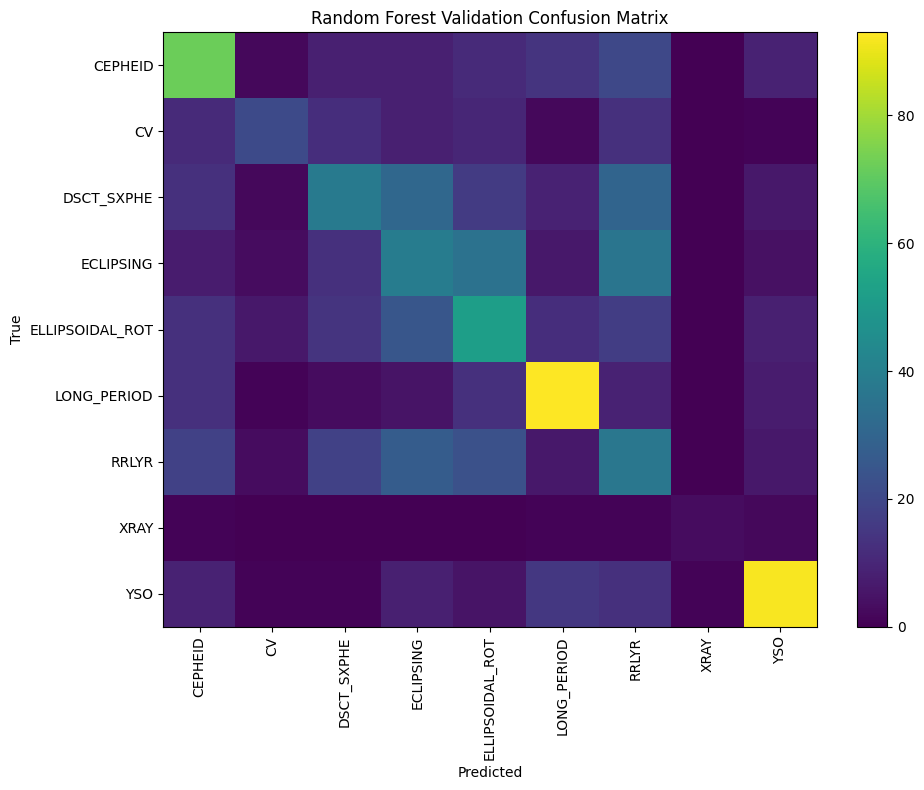

In [11]:
Labels = sorted(yVal.unique())

ConfMat = confusion_matrix(yVal, RandomForestValPred, labels=Labels)
ConfMatDf = pd.DataFrame(ConfMat, index=Labels, columns=Labels)

display(ConfMatDf)

plt.figure(figsize=(10, 8))
plt.imshow(ConfMat, aspect="auto")
plt.xticks(range(len(Labels)), Labels, rotation=90)
plt.yticks(range(len(Labels)), Labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 11 — Feature Importance

Random Forest impurity-based feature importance is extracted from the trained model, ranked, and plotted.


,Feature,Importance
19,EtaVonNeumann,0.046418
2,OriginalFluxStd,0.041453
28,LsPeriod3,0.039066
21,MedianAbsSuccessiveDiff,0.038152
20,MaxAbsSlope,0.037089
24,LsBestPeriod,0.036166
27,LsPeriod2,0.034597
3,CadenceCount,0.033368
18,TailRatio,0.033097
25,LsMaxPower,0.032032


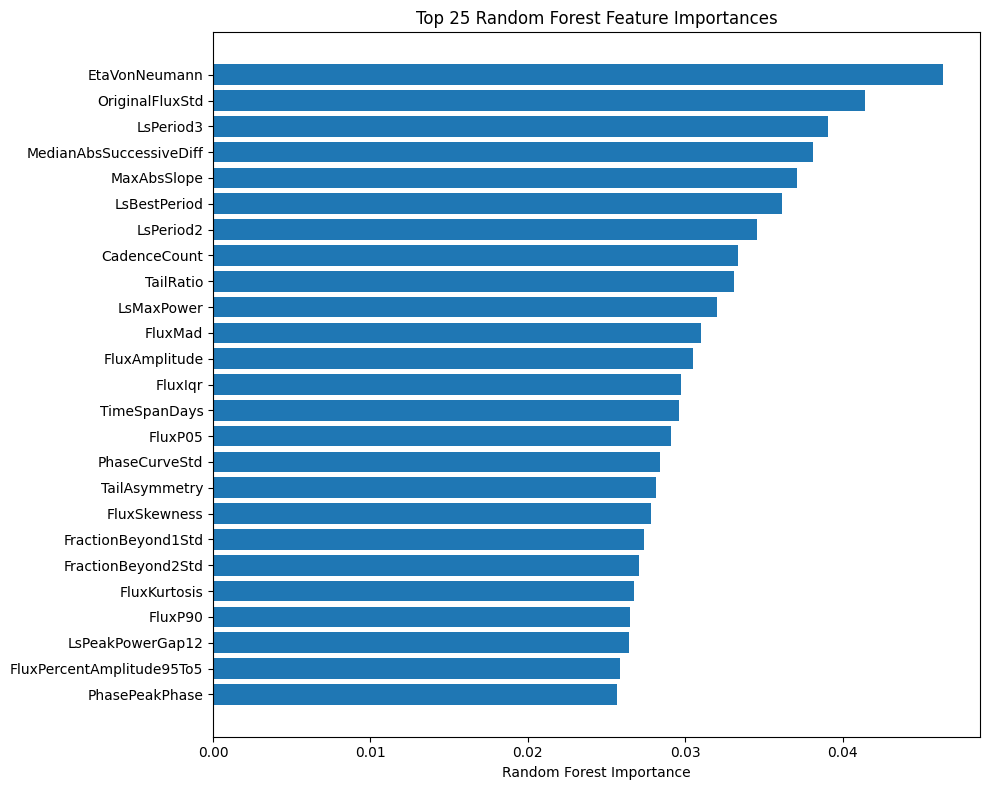

In [12]:
RfClassifier = RandomForestModel.named_steps["model"]

ImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "Importance": RfClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ImportanceDf.head(30))

TopN = 25
TopImportance = ImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(TopImportance["Feature"], TopImportance["Importance"])
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TopN} Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## Step 12 — Permutation Importance

Permutation importance provides a held-out complement to impurity-based importance. Each validation predictor is shuffled while the trained model remains fixed, and the resulting performance change measures model dependence on that predictor.


,Feature,PermutationImportanceMean,PermutationImportanceStd
0,MedianCadenceDays,0.043494,0.000630
1,MedianAbsSuccessiveDiff,0.040936,0.004441
2,OriginalFluxStd,0.038675,0.008236
3,FluxPercentAmplitude95To5,0.037260,0.001717
4,CadenceCount,0.035171,0.007338
5,LsPeriod3,0.033231,0.002435
6,MaxAbsSlope,0.032525,0.006313
7,FluxKurtosis,0.031592,0.006171
8,FluxP90,0.028714,0.006016
9,LsBestPeriod,0.026381,0.007510


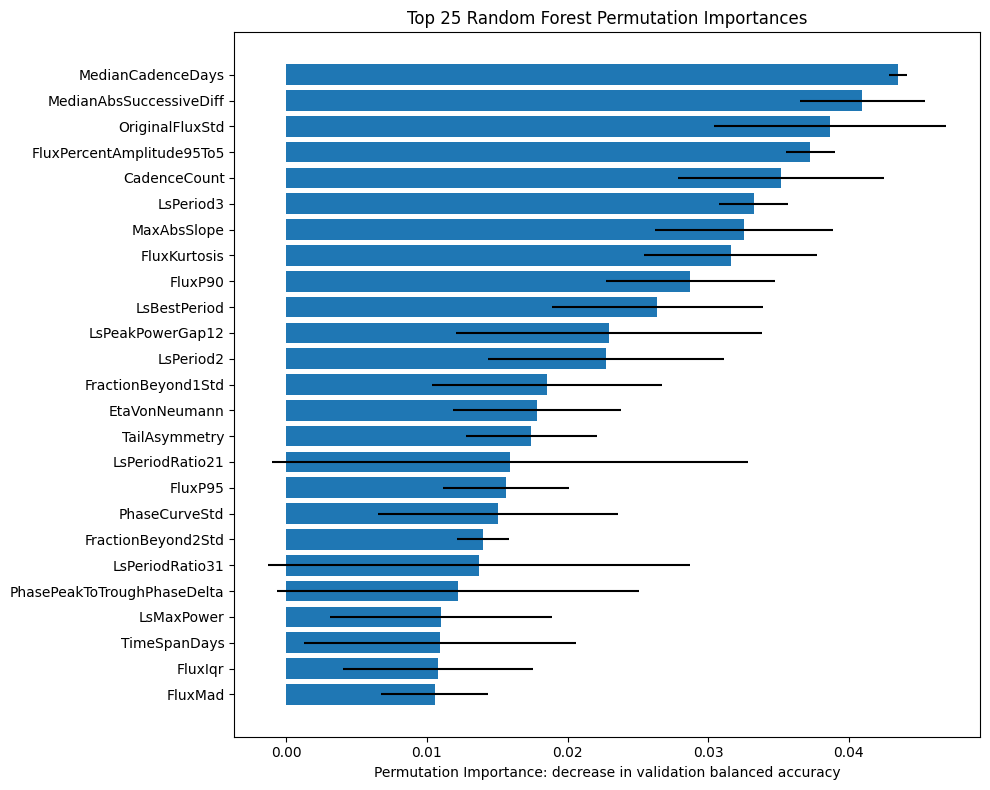

6100

In [13]:
from sklearn.inspection import permutation_importance
import gc

# Remove any large stale permutation result from an earlier run.
for VariableName in [
    "PermutationResult",
    "PermutationImportanceDf",
    "TopPermutationImportance",
]:
    if VariableName in globals():
        del globals()[VariableName]

gc.collect()

# n_jobs=1 avoids duplicating XVal and model data across worker processes.
# Five repeats are normally enough for this diagnostic analysis.
PermutationResult = permutation_importance(
    RandomForestModel,
    XVal,
    yVal,
    n_repeats=5,
    random_state=RandomState,
    scoring="balanced_accuracy",
    n_jobs=2,
)

# Copy only the compact summary arrays that are needed later.
PermutationImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "PermutationImportanceMean":
        PermutationResult.importances_mean.copy(),
    "PermutationImportanceStd":
        PermutationResult.importances_std.copy(),
}).sort_values(
    "PermutationImportanceMean",
    ascending=False,
).reset_index(drop=True)

# The full result also contains an
# n_features × n_repeats importance matrix.
# It is no longer needed after extracting mean and standard deviation.
del PermutationResult
gc.collect()

display(PermutationImportanceDf.head(30))

TopN = 25
TopPermutationImportance = (
    PermutationImportanceDf
    .head(TopN)
    .iloc[::-1]
    .copy()
)

plt.figure(figsize=(10, 8))
plt.barh(
    TopPermutationImportance["Feature"],
    TopPermutationImportance["PermutationImportanceMean"],
    xerr=TopPermutationImportance["PermutationImportanceStd"],
)
plt.xlabel(
    "Permutation Importance: decrease in validation balanced accuracy"
)
plt.title(f"Top {TopN} Random Forest Permutation Importances")
plt.tight_layout()
plt.show()
plt.close()

del TopPermutationImportance
gc.collect()

## Step 13 — Final Test Evaluation

The selected Random Forest is evaluated on the held-out test set using accuracy, balanced accuracy, and per-family classification metrics.


In [14]:
RandomForestTestPred = RandomForestModel.predict(XTest)

RandomForestTestAccuracy = accuracy_score(yTest, RandomForestTestPred)
RandomForestTestBalancedAccuracy = balanced_accuracy_score(yTest, RandomForestTestPred)

print("Random Forest Test Accuracy:", RandomForestTestAccuracy)
print("Random Forest Test Balanced Accuracy:", RandomForestTestBalancedAccuracy)
print()
print(classification_report(yTest, RandomForestTestPred))


Random Forest Test Accuracy: 0.39158279963403475
Random Forest Test Balanced Accuracy: 0.34030757854177235

                 precision    recall  f1-score   support

        CEPHEID       0.47      0.52      0.50       145
             CV       0.46      0.22      0.30        77
     DSCT_SXPHE       0.31      0.24      0.27       145
      ECLIPSING       0.20      0.23      0.22       144
ELLIPSOIDAL_ROT       0.30      0.31      0.30       148
    LONG_PERIOD       0.67      0.65      0.66       144
          RRLYR       0.16      0.23      0.19       137
           XRAY       0.00      0.00      0.00         7
            YSO       0.72      0.66      0.69       146

       accuracy                           0.39      1093
      macro avg       0.37      0.34      0.35      1093
   weighted avg       0.41      0.39      0.40      1093



/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

## Step 14 — Error Analysis: Correct vs Incorrect and Accuracy by Data Source

This section uses row-level predictions to diagnose *why* the model is making mistakes, not just how often it is wrong.

Two quick, high-value checks are included:

1. Compare correctly classified vs incorrectly classified samples using key period/amplitude/power features.
2. Compare accuracy by data provenance/source, such as SPOC, QLP, and TESSCut when the provenance column is available.

In [15]:
def firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def buildErrorAnalysisDf(SourceDf, X, y, SplitName):
    Df = SourceDf.copy()
    Df["split"] = SplitName
    Df["label"] = y.values
    Df["prediction"] = RandomForestModel.predict(X)
    Df["correct"] = Df["prediction"] == Df["label"]
    return Df


TrainErrorDf = buildErrorAnalysisDf(TrainDf, XTrain, yTrain, "train")
ValErrorDf = buildErrorAnalysisDf(ValDf, XVal, yVal, "validation")
TestErrorDf = buildErrorAnalysisDf(TestDf, XTest, yTest, "test")

ErrorAnalysisDf = pd.concat(
    [TrainErrorDf, ValErrorDf, TestErrorDf],
    ignore_index=True,
)

print("Random Forest accuracy by split:")
display(
    ErrorAnalysisDf
    .groupby("split")["correct"]
    .agg(accuracy="mean", sample_count="size")
    .reset_index()
)

# Pick the most useful available columns for the quick correct-vs-incorrect comparison.
BestPeriodColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPeriod",
        "LombScargleBestPeriod",
        "LsBestPeriod",
        "Period",
        "period",
        "best_period",
        "Period1",
        "LsPeak1Period",
    ],
)

AmplitudeColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "FluxAmplitude",
        "FluxPercentAmplitude95To5",
        "FluxPercentAmplitude90To10",
        "Amplitude",
        "amplitude",
    ],
)

PowerColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPower",
        "LombScargleBestPower",
        "LsBestPower",
        "LsPeak1Power",
        "Power1",
        "power",
    ],
)

DiagnosticColumns = [
    Col for Col in [BestPeriodColumn, AmplitudeColumn, PowerColumn]
    if Col is not None and Col in ErrorAnalysisDf.columns
]

print("Columns used for correct-vs-incorrect comparison:", DiagnosticColumns)

if DiagnosticColumns:
    CorrectVsIncorrectDf = (
        ErrorAnalysisDf
        .groupby("correct")[DiagnosticColumns]
        .agg(["mean", "median", "std", "count"])
    )
    display(CorrectVsIncorrectDf)
else:
    print("No matching period/amplitude/power diagnostic columns were found.")

# Accuracy by data source/provenance. This is important because SPOC, QLP, and TESSCut can have different noise and preprocessing behavior.
ProvenanceColumn = firstExistingColumn(
    ErrorAnalysisDf,
    ["Provenance", "provenance", "Source", "source", "LightCurveSource", "DataSource"],
)

if ProvenanceColumn is not None:
    print(f"Accuracy by data source using column: {ProvenanceColumn}")
    AccuracyBySourceDf = (
        ErrorAnalysisDf
        .groupby(["split", ProvenanceColumn])["correct"]
        .agg(accuracy="mean", sample_count="size")
        .reset_index()
        .sort_values(["split", "accuracy"], ascending=[True, False])
    )
    display(AccuracyBySourceDf)
else:
    print("No provenance/source column found. Accuracy-by-source analysis was skipped.")

# Top validation/test confusion pairs are often easier to interpret than the full confusion matrix.
TopConfusionPairsDf = (
    ErrorAnalysisDf
    .query("split in ['validation', 'test'] and correct == False")
    .groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

print("Top validation/test confusion pairs:")
display(TopConfusionPairsDf)


Random Forest accuracy by split:


,split,accuracy,sample_count
0,test,0.391583,1093
1,train,1.000000,5096
2,validation,0.409341,1092


Columns used for correct-vs-incorrect comparison: ['LsBestPeriod', 'FluxAmplitude']


LsBestPeriod                             FluxAmplitude                            
                mean     median        std count          mean     median        std count
correct                                                                                   
False      17.465486  14.386566  15.311263  1310     31.408441  23.716786  28.038533  1310
True       16.610961  14.347948  15.929200  5971     30.314143  21.735608  29.550684  5971

Accuracy by data source using column: Provenance


,split,Provenance,accuracy,sample_count
1,test,SPOC,0.791667,72
0,test,QLP,0.700535,187
2,test,TESSCut,0.287770,834
3,train,QLP,1.000000,988
4,train,SPOC,1.000000,353
5,train,TESSCut,1.000000,3755
7,validation,SPOC,0.797619,84
6,validation,QLP,0.668539,178
8,validation,TESSCut,0.314458,830


Top validation/test confusion pairs:


,label,prediction,count
26,ECLIPSING,RRLYR,72
19,DSCT_SXPHE,RRLYR,67
24,ECLIPSING,ELLIPSOIDAL_ROT,61
16,DSCT_SXPHE,ECLIPSING,60
31,ELLIPSOIDAL_ROT,ECLIPSING,57
45,RRLYR,ECLIPSING,55
33,ELLIPSOIDAL_ROT,RRLYR,48
5,CEPHEID,RRLYR,47
44,RRLYR,DSCT_SXPHE,45
46,RRLYR,ELLIPSOIDAL_ROT,44


## Step 15 — Save Useful Outputs

The model-comparison table, feature-importance table, and validation confusion matrix are saved under `OutputDir` for reporting and manuscript traceability.


In [16]:
# Save summary artifacts
ComparisonPath = OutputDir / "model_comparison_validation.csv"
ImportancePath = OutputDir / "random_forest_feature_importance.csv"
PermutationImportancePath = OutputDir / "random_forest_permutation_importance.csv"
ConfusionPath = OutputDir / "random_forest_validation_confusion_matrix.csv"
ErrorAnalysisPath = OutputDir / "random_forest_error_analysis.parquet"
AccuracyBySourcePath = OutputDir / "random_forest_accuracy_by_source.csv"
TopConfusionPairsPath = OutputDir / "random_forest_top_confusion_pairs.csv"

ComparisonDf.to_csv(ComparisonPath, index=False)
ImportanceDf.to_csv(ImportancePath, index=False)
if "PermutationImportanceDf" in globals():
    PermutationImportanceDf.to_csv(PermutationImportancePath, index=False)
ConfMatDf.to_csv(ConfusionPath)
if "ErrorAnalysisDf" in globals():
    ErrorAnalysisDf.to_parquet(ErrorAnalysisPath, index=False)
if "AccuracyBySourceDf" in globals():
    AccuracyBySourceDf.to_csv(AccuracyBySourcePath, index=False)
if "TopConfusionPairsDf" in globals():
    TopConfusionPairsDf.to_csv(TopConfusionPairsPath, index=False)

# Save row-level train / validation / test predictions.
# These files keep the original metadata/features and append prediction columns,
# which makes later error analysis much easier.
def BuildPredictionOutputDf(SourceDf, X, y, SplitName):
    OutputDf = SourceDf.copy()

    LogisticPred = LogisticModel.predict(X)
    RandomForestPred = RandomForestModel.predict(X)

    OutputDf["Split"] = SplitName
    OutputDf["ActualFamily"] = y.values
    OutputDf["LogisticRegressionPrediction"] = LogisticPred
    OutputDf["RandomForestPrediction"] = RandomForestPred
    OutputDf["LogisticRegressionCorrect"] = OutputDf["ActualFamily"] == OutputDf["LogisticRegressionPrediction"]
    OutputDf["RandomForestCorrect"] = OutputDf["ActualFamily"] == OutputDf["RandomForestPrediction"]

    return OutputDf

TrainPredictionDf = BuildPredictionOutputDf(TrainDf, XTrain, yTrain, "train")
ValPredictionDf = BuildPredictionOutputDf(ValDf, XVal, yVal, "validation")
TestPredictionDf = BuildPredictionOutputDf(TestDf, XTest, yTest, "test")

TrainPredictionPath = OutputDir / "train_predictions.parquet"
ValPredictionPath = OutputDir / "validation_predictions.parquet"
TestPredictionPath = OutputDir / "test_predictions.parquet"

TrainPredictionDf.to_parquet(TrainPredictionPath, index=False)
ValPredictionDf.to_parquet(ValPredictionPath, index=False)
TestPredictionDf.to_parquet(TestPredictionPath, index=False)

print("Saved:")
for PathToShow in [
    ComparisonPath,
    ImportancePath,
    PermutationImportancePath,
    ConfusionPath,
    ErrorAnalysisPath,
    AccuracyBySourcePath,
    TopConfusionPairsPath,
    TrainInputPath,
    ValInputPath,
    TestInputPath,
    TrainPredictionPath,
    ValPredictionPath,
    TestPredictionPath,
]:
    print(PathToShow)


Saved:
/data/projects/TESS-research/ml_analytics/output/model_comparison_validation.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_feature_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_permutation_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_validation_confusion_matrix.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_error_analysis.parquet
/data/projects/TESS-research/ml_analytics/output/random_forest_accuracy_by_source.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_top_confusion_pairs.csv
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet
/data/projects/TESS-research/ml_analytics/output/train_predictions.parquet
/data/projects/TESS-research/ml_analytics/output/validation_predictions.parquet
/data/projects/T

## Step 16 — Findings, Diagnosis, Key Insights, Bottlenecks, and Next Steps

This section is generated from the actual Python objects created in the preceding steps. No model metrics, sample counts, provenance results, or confusion counts are hardcoded.


In [17]:
from IPython.display import Markdown, display


def _formatMetric(Value, Digits=3):
    if pd.isna(Value):
        return "N/A"
    return f"{float(Value):.{Digits}f}"


def _displayTable(Df, FloatDigits=3):
    """Display a DataFrame without requiring the optional tabulate package."""
    DisplayDf = Df.copy()
    FloatColumns = [
        ColumnName
        for ColumnName in DisplayDf.columns
        if pd.api.types.is_float_dtype(DisplayDf[ColumnName])
    ]
    FormatMap = {
        ColumnName: f"{{:.{FloatDigits}f}}"
        for ColumnName in FloatColumns
    }
    display(
        DisplayDf.style
        .format(FormatMap, na_rep="N/A")
        .hide(axis="index")
    )


# 1. Model comparison and split-level Random Forest performance
RequiredComparisonColumns = {
    "Model",
    "ValidationAccuracy",
    "ValidationBalancedAccuracy",
}
MissingComparisonColumns = sorted(
    RequiredComparisonColumns - set(ComparisonDf.columns)
)
if MissingComparisonColumns:
    raise ValueError(
        "ComparisonDf is missing required columns: "
        + str(MissingComparisonColumns)
    )

ModelSummaryDf = ComparisonDf[
    [
        "Model",
        "ValidationAccuracy",
        "ValidationBalancedAccuracy",
    ]
].copy()
ModelSummaryDf = ModelSummaryDf.rename(
    columns={
        "ValidationAccuracy": "Validation accuracy",
        "ValidationBalancedAccuracy": "Validation balanced accuracy",
    }
)

SplitSummaryDf = (
    ErrorAnalysisDf
    .groupby("split", as_index=False)["correct"]
    .agg(Accuracy="mean", **{"Sample count": "size"})
)
PreferredSplitOrder = pd.CategoricalDtype(
    ["train", "validation", "test"], ordered=True
)
SplitSummaryDf["split"] = SplitSummaryDf["split"].astype(
    PreferredSplitOrder
)
SplitSummaryDf = (
    SplitSummaryDf
    .sort_values("split")
    .rename(columns={"split": "Split"})
)
SplitSummaryDf["Split"] = (
    SplitSummaryDf["Split"].astype(str).str.title()
)

LogisticRow = ComparisonDf[
    ComparisonDf["Model"].astype(str).str.contains(
        "Logistic", case=False, na=False
    )
]
RandomForestRow = ComparisonDf[
    ComparisonDf["Model"].astype(str).str.contains(
        "Random Forest", case=False, na=False
    )
]

if len(LogisticRow) and len(RandomForestRow):
    LogisticAccuracy = float(
        LogisticRow.iloc[0]["ValidationAccuracy"]
    )
    RandomForestAccuracy = float(
        RandomForestRow.iloc[0]["ValidationAccuracy"]
    )
    AccuracyImprovement = RandomForestAccuracy - LogisticAccuracy

    LogisticBalancedAccuracy = float(
        LogisticRow.iloc[0]["ValidationBalancedAccuracy"]
    )
    RandomForestBalancedAccuracy = float(
        RandomForestRow.iloc[0]["ValidationBalancedAccuracy"]
    )
    BalancedAccuracyImprovement = (
        RandomForestBalancedAccuracy - LogisticBalancedAccuracy
    )
else:
    AccuracyImprovement = np.nan
    BalancedAccuracyImprovement = np.nan

SplitAccuracyLookup = {
    str(Row["Split"]).lower(): float(Row["Accuracy"])
    for _, Row in SplitSummaryDf.iterrows()
}
TrainAccuracy = SplitAccuracyLookup.get("train", np.nan)
ValidationAccuracy = SplitAccuracyLookup.get("validation", np.nan)
TestAccuracy = SplitAccuracyLookup.get("test", np.nan)

GeneralizationGap = (
    TrainAccuracy - TestAccuracy
    if np.isfinite(TrainAccuracy) and np.isfinite(TestAccuracy)
    else np.nan
)
ValidationTestDifference = (
    abs(ValidationAccuracy - TestAccuracy)
    if np.isfinite(ValidationAccuracy) and np.isfinite(TestAccuracy)
    else np.nan
)

if np.isfinite(GeneralizationGap):
    if GeneralizationGap >= 0.20:
        OverfittingText = (
            "The large train-to-test gap indicates substantial overfitting."
        )
    elif GeneralizationGap >= 0.10:
        OverfittingText = (
            "The train-to-test gap indicates moderate overfitting."
        )
    else:
        OverfittingText = "The train-to-test gap is relatively small."
else:
    OverfittingText = (
        "The train-to-test generalization gap could not be calculated."
    )

if np.isfinite(ValidationTestDifference):
    if ValidationTestDifference <= 0.03:
        StabilityText = (
            "Validation and test accuracy are close, suggesting that "
            "the held-out evaluation is reasonably stable."
        )
    else:
        StabilityText = (
            "Validation and test accuracy differ noticeably, so split "
            "sensitivity should be considered."
        )
else:
    StabilityText = "Validation/test stability could not be evaluated."

if np.isfinite(AccuracyImprovement):
    ImprovementSentence = (
        f"Random Forest improves validation accuracy by "
        f"**{_formatMetric(AccuracyImprovement)}** and validation "
        f"balanced accuracy by "
        f"**{_formatMetric(BalancedAccuracyImprovement)}** relative "
        f"to Logistic Regression."
    )
else:
    ImprovementSentence = (
        "The Random Forest-versus-Logistic Regression improvement "
        "could not be calculated."
    )


display(Markdown("### 1. Random Forest improvement over Logistic Regression"))
_displayTable(ModelSummaryDf, FloatDigits=3)
display(Markdown("**Observed Random Forest performance by split**"))
_displayTable(SplitSummaryDf, FloatDigits=3)
display(Markdown(
    "**Interpretation**\n\n"
    f"- {ImprovementSentence}\n"
    f"- {OverfittingText}\n"
    f"- {StabilityText}\n"
    f"- Train-to-test accuracy gap: **{_formatMetric(GeneralizationGap)}**.\n"
    f"- Absolute validation-to-test accuracy difference: "
    f"**{_formatMetric(ValidationTestDifference)}**."
))


# 2. Correct-versus-incorrect diagnostic feature comparison
display(Markdown("### 2. Correct-versus-incorrect diagnostic comparison"))

DiagnosticInterpretation = (
    "The simple correct-versus-incorrect diagnostic could not be evaluated."
)
DiagnosticDisplayDf = None

if "DiagnosticColumns" in globals() and DiagnosticColumns:
    ExistingDiagnosticColumns = [
        ColumnName
        for ColumnName in DiagnosticColumns
        if ColumnName in ErrorAnalysisDf.columns
    ]

    if ExistingDiagnosticColumns:
        DiagnosticRows = []
        for CorrectValue, GroupDf in ErrorAnalysisDf.groupby("correct"):
            Row = {
                "Correct?": bool(CorrectValue),
                "Count": int(len(GroupDf)),
            }
            for ColumnName in ExistingDiagnosticColumns:
                NumericValues = pd.to_numeric(
                    GroupDf[ColumnName], errors="coerce"
                )
                Row[f"Mean {ColumnName}"] = NumericValues.mean()
                Row[f"Median {ColumnName}"] = NumericValues.median()
            DiagnosticRows.append(Row)

        DiagnosticDisplayDf = (
            pd.DataFrame(DiagnosticRows)
            .sort_values("Correct?")
            .reset_index(drop=True)
        )

        DifferenceStatements = []
        for ColumnName in ExistingDiagnosticColumns:
            IncorrectValues = pd.to_numeric(
                ErrorAnalysisDf.loc[
                    ErrorAnalysisDf["correct"] == False,
                    ColumnName,
                ],
                errors="coerce",
            )
            CorrectValues = pd.to_numeric(
                ErrorAnalysisDf.loc[
                    ErrorAnalysisDf["correct"] == True,
                    ColumnName,
                ],
                errors="coerce",
            )
            IncorrectMedian = IncorrectValues.median()
            CorrectMedian = CorrectValues.median()

            if np.isfinite(IncorrectMedian) and np.isfinite(CorrectMedian):
                Scale = max(
                    abs(IncorrectMedian), abs(CorrectMedian), 1e-12
                )
                RelativeDifference = (
                    abs(IncorrectMedian - CorrectMedian) / Scale
                )
                if RelativeDifference < 0.10:
                    DifferenceText = "very similar"
                elif RelativeDifference < 0.25:
                    DifferenceText = "moderately different"
                else:
                    DifferenceText = "substantially different"

                DifferenceStatements.append(
                    f"- Median `{ColumnName}` values are "
                    f"{DifferenceText} between correct and incorrect "
                    f"samples ({_formatMetric(CorrectMedian)} versus "
                    f"{_formatMetric(IncorrectMedian)})."
                )

        if DifferenceStatements:
            DiagnosticInterpretation = "\n".join(DifferenceStatements)

DiagnosticColumnText = (
    ", ".join(DiagnosticColumns)
    if "DiagnosticColumns" in globals() and DiagnosticColumns
    else "none"
)
display(Markdown(f"Columns used: `{DiagnosticColumnText}`"))
if DiagnosticDisplayDf is not None:
    _displayTable(DiagnosticDisplayDf, FloatDigits=3)
else:
    display(Markdown("No period, amplitude, or power diagnostic columns were available."))

display(Markdown(
    "**Interpretation**\n\n"
    f"{DiagnosticInterpretation}\n\n"
    "These simple diagnostics should be treated as descriptive evidence. "
    "Similar medians do not prove that a feature is unimportant, because "
    "nonlinear interactions and distribution tails may still contribute "
    "to classification."
))


# 3. Accuracy by light-curve provenance
display(Markdown("### 3. Accuracy by light-curve provenance"))
SourceInterpretation = "Accuracy by provenance could not be evaluated."
SourceDisplayDf = None

if (
    "AccuracyBySourceDf" in globals()
    and isinstance(AccuracyBySourceDf, pd.DataFrame)
    and len(AccuracyBySourceDf)
):
    SourceDisplayDf = AccuracyBySourceDf.copy().rename(
        columns={
            "split": "Split",
            "accuracy": "Accuracy",
            "sample_count": "Sample count",
        }
    )
    ProvenanceDisplayColumn = next(
        (
            ColumnName
            for ColumnName in SourceDisplayDf.columns
            if ColumnName not in {"Split", "Accuracy", "Sample count"}
        ),
        None,
    )

    if ProvenanceDisplayColumn is not None:
        SourceDisplayDf = SourceDisplayDf.rename(
            columns={ProvenanceDisplayColumn: "Provenance"}
        )
        SourceDisplayDf["Split"] = (
            SourceDisplayDf["Split"].astype(str).str.title()
        )
        SourceDisplayDf = SourceDisplayDf[
            ["Split", "Provenance", "Accuracy", "Sample count"]
        ]

        HeldOutSourceDf = SourceDisplayDf[
            SourceDisplayDf["Split"].isin(["Validation", "Test"])
        ].copy()

        if len(HeldOutSourceDf):
            SourceAggregateRows = []
            for ProvenanceValue, GroupDf in HeldOutSourceDf.groupby(
                "Provenance"
            ):
                SourceAggregateRows.append({
                    "Provenance": ProvenanceValue,
                    "WeightedAccuracy": np.average(
                        GroupDf["Accuracy"],
                        weights=GroupDf["Sample count"],
                    ),
                    "SampleCount": GroupDf["Sample count"].sum(),
                })
            SourceAggregateDf = (
                pd.DataFrame(SourceAggregateRows)
                .sort_values("WeightedAccuracy", ascending=False)
                .reset_index(drop=True)
            )
            BestSourceRow = SourceAggregateDf.iloc[0]
            WorstSourceRow = SourceAggregateDf.iloc[-1]
            ProvenanceGap = (
                BestSourceRow["WeightedAccuracy"]
                - WorstSourceRow["WeightedAccuracy"]
            )
            SourceInterpretation = (
                f"- Best held-out provenance: "
                f"**{BestSourceRow['Provenance']}** "
                f"({_formatMetric(BestSourceRow['WeightedAccuracy'])}).\n"
                f"- Lowest held-out provenance: "
                f"**{WorstSourceRow['Provenance']}** "
                f"({_formatMetric(WorstSourceRow['WeightedAccuracy'])}).\n"
                f"- Held-out accuracy gap: "
                f"**{_formatMetric(ProvenanceGap)}**.\n"
                f"- This observed gap shows that model performance varies "
                f"with light-curve provenance in the current dataset. It "
                f"should be interpreted as an association, not by itself "
                f"as proof that provenance is the sole cause."
            )

if SourceDisplayDf is not None:
    _displayTable(SourceDisplayDf, FloatDigits=3)
else:
    display(Markdown("No provenance/source column was available."))
display(Markdown(f"**Interpretation**\n\n{SourceInterpretation}"))


# 4. Top held-out confusion pairs
display(Markdown("### 4. Top validation/test confusion pairs"))
ConfusionInterpretation = (
    "The dominant class confusions could not be summarized."
)
ConfusionDisplayDf = None

if (
    "TopConfusionPairsDf" in globals()
    and isinstance(TopConfusionPairsDf, pd.DataFrame)
    and len(TopConfusionPairsDf)
):
    ConfusionDisplayDf = TopConfusionPairsDf.copy().rename(
        columns={
            "label": "True label",
            "prediction": "Predicted label",
            "count": "Count",
        }
    )
    TopPair = ConfusionDisplayDf.iloc[0]
    ConfusionInterpretation = (
        f"The most frequent held-out error is "
        f"**{TopPair['True label']} → {TopPair['Predicted label']}** "
        f"with **{int(TopPair['Count'])}** cases. The full table "
        f"identifies which physical families remain most difficult "
        f"to separate."
    )

if ConfusionDisplayDf is not None:
    _displayTable(ConfusionDisplayDf, FloatDigits=0)
else:
    display(Markdown("No held-out confusion-pair table was available."))
display(Markdown(f"**Interpretation**\n\n{ConfusionInterpretation}"))


# 5. Current diagnosis and next steps
display(Markdown(
    """### 5. Current diagnosis

The results above support the following data-driven diagnosis:

1. The Random Forest captures nonlinear information beyond the Logistic Regression baseline.
2. Any train-to-test gap shown above quantifies overfitting directly rather than relying on an old saved result.
3. Provenance-specific performance differences are measured from the current notebook run and should be considered when interpreting overall accuracy.
4. The confusion table identifies the family pairs that are currently the dominant classification bottlenecks.
5. The correct-versus-incorrect feature summary tests whether simple signal descriptors alone distinguish easy and difficult cases.

### 6. Recommended next steps

1. Evaluate the single mixed-provenance Random Forest separately on held-out SPOC, QLP, and TESSCut predictions.
2. Report family-by-provenance performance with sample counts, so small groups are not overinterpreted.
3. Use bootstrap confidence intervals for provenance-specific accuracy and balanced accuracy.
4. Investigate the largest confusion pairs using phase-folded light-curve morphology and representative examples.
5. Compare permutation importance across provenance only after controlling for family composition and sample size.
"""
))


### 1. Random Forest improvement over Logistic Regression

Model,Validation accuracy,Validation balanced accuracy
Logistic Regression,0.270,0.321
Random Forest,0.409,0.398


**Observed Random Forest performance by split**

Split,Accuracy,Sample count
Train,1.000,5096
Validation,0.409,1092
Test,0.392,1093


**Interpretation**

- Random Forest improves validation accuracy by **0.139** and validation balanced accuracy by **0.077** relative to Logistic Regression.
- The large train-to-test gap indicates substantial overfitting.
- Validation and test accuracy are close, suggesting that the held-out evaluation is reasonably stable.
- Train-to-test accuracy gap: **0.608**.
- Absolute validation-to-test accuracy difference: **0.018**.

...

**Interpretation**

- Best held-out provenance: **SPOC** (0.795).
- Lowest held-out provenance: **TESSCut** (0.301).
- Held-out accuracy gap: **0.494**.
- This observed gap shows that model performance varies with light-curve provenance in the current dataset. It should be interpreted as an association, not by itself as proof that provenance is the sole cause.

### 4. Top validation/test confusion pairs

True label,Predicted label,Count
ECLIPSING,RRLYR,72
DSCT_SXPHE,RRLYR,67
ECLIPSING,ELLIPSOIDAL_ROT,61
DSCT_SXPHE,ECLIPSING,60
ELLIPSOIDAL_ROT,ECLIPSING,57
RRLYR,ECLIPSING,55
ELLIPSOIDAL_ROT,RRLYR,48
CEPHEID,RRLYR,47
RRLYR,DSCT_SXPHE,45
RRLYR,ELLIPSOIDAL_ROT,44


**Interpretation**

The most frequent held-out error is **ECLIPSING → RRLYR** with **72** cases. The full table identifies which physical families remain most difficult to separate.

### 5. Current diagnosis

The results above support the following data-driven diagnosis:

1. The Random Forest captures nonlinear information beyond the Logistic Regression baseline.
2. Any train-to-test gap shown above quantifies overfitting directly rather than relying on an old saved result.
3. Provenance-specific performance differences are measured from the current notebook run and should be considered when interpreting overall accuracy.
4. The confusion table identifies the family pairs that are currently the dominant classification bottlenecks.
5. The correct-versus-incorrect feature summary tests whether simple signal descriptors alone distinguish easy and difficult cases.

### 6. Recommended next steps

1. Evaluate the single mixed-provenance Random Forest separately on held-out SPOC, QLP, and TESSCut predictions.
2. Report family-by-provenance performance with sample counts, so small groups are not overinterpreted.
3. Use bootstrap confidence intervals for provenance-specific accuracy and balanced accuracy.
4. Investigate the largest confusion pairs using phase-folded light-curve morphology and representative examples.
5. Compare permutation importance across provenance only after controlling for family composition and sample size.


## Step 17 — Controlled Conditional Detrending Experiment

### Goal

This experiment tests whether conditional detrending of eligible TESSCut light curves improves classification while holding the downstream modeling setup fixed.

The conditional-detrended feature table preserves the full mixed-provenance modeling sample. SPOC and QLP rows remain unchanged, while eligible TESSCut rows use features extracted from the conditionally detrended light curves.

For a controlled comparison, this step now reuses:

- the canonical train/validation/test star assignments;
- the common 39-feature predictor set;
- the canonical median-imputation pipeline;
- the canonical 500-tree Random Forest configuration with `class_weight="balanced_subsample"`;
- the canonical random state.

The analysis reports both overall held-out performance and performance restricted to the TESSCut stars within the canonical held-out test set. Therefore, the principal experimental change is the conditional detrending applied upstream to eligible TESSCut light curves.


In [18]:

# ============================================================
# TESSCut conditional-detrending metadata preparation
# ============================================================

# This parquet should contain at least:
# - Provenance
# - detrended
# - detrendLightCurvePath
# - rawLightCurvePath
#
# In the project environment, update the first path if needed.

TessCutConditionalMetadataPath = Project_Root / "detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet"

TessCutMetaDf = pd.read_parquet(TessCutConditionalMetadataPath)

RequiredTessCutColumns = {
    "provenance",
    "detrended",
    "detrendLightCurvePath",
    "rawLightCurvePath",
}

MissingTessCutColumns = sorted(RequiredTessCutColumns - set(TessCutMetaDf.columns))
if MissingTessCutColumns:
    raise ValueError(f"Missing required columns in metadata parquet: {MissingTessCutColumns}")

# Keep only TESSCut rows.
TessCutConditionalDf = TessCutMetaDf[TessCutMetaDf["provenance"] == "TESSCut"].copy()

# Robustly convert detrended flag to boolean.
# This handles True/False, 1/0, and common string values such as "true"/"false".
DetrendedFlag = (
    TessCutConditionalDf["detrended"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes", "y"])
)

# Use detrended FITS where available; otherwise use raw FITS.
TessCutConditionalDf["selectedLightCurvePath"] = np.where(
    DetrendedFlag,
    TessCutConditionalDf["detrendLightCurvePath"],
    TessCutConditionalDf["rawLightCurvePath"],
)

TessCutConditionalDf["selectedLightCurveSource"] = np.where(
    DetrendedFlag,
    "detrended",
    "raw_fallback",
)

# Preserve original columns but also overwrite lightCurvePath for downstream feature extraction.
# This makes the selected path easy to consume by existing feature extraction code.
TessCutConditionalDf["originalRawLightCurvePath"] = TessCutConditionalDf["rawLightCurvePath"]
TessCutConditionalDf["originalDetrendLightCurvePath"] = TessCutConditionalDf["detrendLightCurvePath"]

TessCutConditionalDf["lightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]
TessCutConditionalDf["rawLightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]

# Basic path sanity checks.
TessCutConditionalDf["hasSelectedLightCurvePath"] = (
    TessCutConditionalDf["selectedLightCurvePath"].notna()
    & (TessCutConditionalDf["selectedLightCurvePath"].astype(str).str.len() > 0)
)

TessCutConditionalInputPath = OutputDir / "tesscut_conditional_detrended_metadata.parquet"
TessCutConditionalDf.to_parquet(TessCutConditionalInputPath, index=False)

print(f"Loaded metadata: {TessCutConditionalMetadataPath}")
print(f"TESSCut rows: {len(TessCutConditionalDf)}")
print(f"Saved conditional TESSCut metadata to: {TessCutConditionalInputPath}")

display(
    TessCutConditionalDf["selectedLightCurveSource"]
    .value_counts()
    .rename_axis("selected source")
    .reset_index(name="count")
)

display(
    TessCutConditionalDf[[
        "provenance",
        "detrended",
        "selectedLightCurveSource",
        "selectedLightCurvePath",
        "hasSelectedLightCurvePath",
    ]].head(10)
)


Loaded metadata: /data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
TESSCut rows: 5419
Saved conditional TESSCut metadata to: /data/projects/TESS-research/ml_analytics/output/tesscut_conditional_detrended_metadata.parquet


,selected source,count
0,detrended,3523
1,raw_fallback,1896


,provenance,detrended,selectedLightCurveSource,selectedLightCurvePath,hasSelectedLightCurvePath
0,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
1,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
2,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
4,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
5,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
6,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
8,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
9,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
10,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
11,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True


### Prepared conditional-detrending metadata

`tesscut_conditional_detrended_metadata.parquet` contains the TESSCut rows used for conditional-detrending feature extraction. The selected light-curve path uses the detrended FITS file when `detrended == True` and the raw FITS file otherwise. The resulting `TESS_conditional_detrended_features.parquet` is used by the controlled experiment below.


In [19]:
# ============================================================
# Step 17 — Controlled conditional-detrending experiment
# ============================================================
# Purpose:
# Compare the canonical mixed-provenance Random Forest with an otherwise
# identical model whose eligible TESSCut light curves have been conditionally
# detrended. The star identities, 39-feature schema, train/validation/test
# assignments, and RF configuration are held fixed.

TessCutConditionalFeaturePath = Project_Root / "feature_extraction/TESS_conditional_detrended_features.parquet"

TessCutConditionalFeatureDf = pd.read_parquet(
    TessCutConditionalFeaturePath
).copy()

if StatusColumn in TessCutConditionalFeatureDf.columns:
    TessCutConditionalFeatureDf = TessCutConditionalFeatureDf[
        TessCutConditionalFeatureDf[StatusColumn]
        .astype(str)
        .str.lower()
        .isin(["ok", "success", "valid", "nan"])
        | TessCutConditionalFeatureDf[StatusColumn].isna()
    ].copy()

# ------------------------------------------------------------
# 1. Verify schema and align to the canonical split by VSXId
# ------------------------------------------------------------
if "VSXId" not in TessCutConditionalFeatureDf.columns:
    raise KeyError(
        "Conditional-detrended feature table must contain VSXId so the "
        "canonical train/validation/test assignments can be reused."
    )

MissingConditionalFeatureColumns = sorted(
    set(FeatureColumns) - set(TessCutConditionalFeatureDf.columns)
)
if MissingConditionalFeatureColumns:
    raise ValueError(
        "Conditional-detrended feature table is missing required model "
        f"features: {MissingConditionalFeatureColumns}"
    )

if TargetColumn not in TessCutConditionalFeatureDf.columns:
    raise KeyError(
        f"Conditional-detrended feature table is missing {TargetColumn}."
    )

for SplitName, SplitDf in [
    ("train", TrainDf),
    ("validation", ValDf),
    ("test", TestDf),
]:
    if "VSXId" not in SplitDf.columns:
        raise KeyError(
            f"Canonical {SplitName} split does not contain VSXId."
        )

if TessCutConditionalFeatureDf["VSXId"].astype(str).duplicated().any():
    DuplicateCount = int(
        TessCutConditionalFeatureDf["VSXId"]
        .astype(str)
        .duplicated()
        .sum()
    )
    raise ValueError(
        "Conditional-detrended feature table contains duplicate VSXId "
        f"values ({DuplicateCount} duplicates)."
    )

TessCutConditionalById = (
    TessCutConditionalFeatureDf
    .assign(VSXId=TessCutConditionalFeatureDf["VSXId"].astype(str))
    .set_index("VSXId", drop=False)
)

def buildConditionalSplit(CanonicalSplitDf, SplitName):
    CanonicalIds = CanonicalSplitDf["VSXId"].astype(str).tolist()

    MissingIds = [
        VSXId for VSXId in CanonicalIds
        if VSXId not in TessCutConditionalById.index
    ]
    if MissingIds:
        raise ValueError(
            f"Conditional-detrended table is missing {len(MissingIds)} "
            f"{SplitName} VSXIds; examples: {MissingIds[:10]}"
        )

    ConditionalSplitDf = (
        TessCutConditionalById
        .loc[CanonicalIds]
        .copy()
        .reset_index(drop=True)
    )

    CanonicalLabels = (
        CanonicalSplitDf[TargetColumn]
        .astype(str)
        .reset_index(drop=True)
    )
    ConditionalLabels = (
        ConditionalSplitDf[TargetColumn]
        .astype(str)
        .reset_index(drop=True)
    )

    if not CanonicalLabels.equals(ConditionalLabels):
        MismatchCount = int(
            (CanonicalLabels != ConditionalLabels).sum()
        )
        raise ValueError(
            f"{SplitName} label mismatch between canonical and "
            f"conditional-detrended tables for {MismatchCount} rows."
        )

    return ConditionalSplitDf


TessCutConditionalTrainDf = buildConditionalSplit(TrainDf, "train")
TessCutConditionalValDf = buildConditionalSplit(ValDf, "validation")
TessCutConditionalTestDf = buildConditionalSplit(TestDf, "test")

print("Canonical split alignment passed.")
print(
    "Conditional train/validation/test:",
    len(TessCutConditionalTrainDf),
    len(TessCutConditionalValDf),
    len(TessCutConditionalTestDf),
)
print("Predictor count:", len(FeatureColumns))

# ------------------------------------------------------------
# 2. Use the exact canonical 39-feature model configuration
# ------------------------------------------------------------
XTessCutConditionalTrain = TessCutConditionalTrainDf[FeatureColumns]
YTessCutConditionalTrain = TessCutConditionalTrainDf[TargetColumn]

XTessCutConditionalVal = TessCutConditionalValDf[FeatureColumns]
YTessCutConditionalVal = TessCutConditionalValDf[TargetColumn]

XTessCutConditionalTest = TessCutConditionalTestDf[FeatureColumns]
YTessCutConditionalTest = TessCutConditionalTestDf[TargetColumn]

TessCutConditionalRfModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

TessCutConditionalRfModel.fit(
    XTessCutConditionalTrain,
    YTessCutConditionalTrain,
)

TessCutConditionalTrainPred = TessCutConditionalRfModel.predict(
    XTessCutConditionalTrain
)
TessCutConditionalValPred = TessCutConditionalRfModel.predict(
    XTessCutConditionalVal
)
TessCutConditionalTestPred = TessCutConditionalRfModel.predict(
    XTessCutConditionalTest
)

# ------------------------------------------------------------
# 3. Direct canonical-vs-detrended comparison on identical splits
# ------------------------------------------------------------
ControlledDetrendPerformanceDf = pd.DataFrame([
    {
        "Model": "Canonical mixed-provenance RF",
        "Split": "validation",
        "Accuracy": accuracy_score(yVal, RandomForestValPred),
        "BalancedAccuracy": balanced_accuracy_score(
            yVal, RandomForestValPred
        ),
        "SampleCount": len(yVal),
    },
    {
        "Model": "Conditional-detrended mixed-provenance RF",
        "Split": "validation",
        "Accuracy": accuracy_score(
            YTessCutConditionalVal,
            TessCutConditionalValPred,
        ),
        "BalancedAccuracy": balanced_accuracy_score(
            YTessCutConditionalVal,
            TessCutConditionalValPred,
        ),
        "SampleCount": len(YTessCutConditionalVal),
    },
    {
        "Model": "Canonical mixed-provenance RF",
        "Split": "test",
        "Accuracy": accuracy_score(yTest, RandomForestTestPred),
        "BalancedAccuracy": balanced_accuracy_score(
            yTest, RandomForestTestPred
        ),
        "SampleCount": len(yTest),
    },
    {
        "Model": "Conditional-detrended mixed-provenance RF",
        "Split": "test",
        "Accuracy": accuracy_score(
            YTessCutConditionalTest,
            TessCutConditionalTestPred,
        ),
        "BalancedAccuracy": balanced_accuracy_score(
            YTessCutConditionalTest,
            TessCutConditionalTestPred,
        ),
        "SampleCount": len(YTessCutConditionalTest),
    },
])

print("Controlled conditional-detrending comparison:")
display(ControlledDetrendPerformanceDf)

# ------------------------------------------------------------
# 4. TESSCut-only evaluation within the identical canonical test stars
# ------------------------------------------------------------
def resolveProvenanceColumn(Df):
    for ColumnName in [
        "Provenance",
        "provenance",
        "Source",
        "source",
        "LightCurveSource",
        "DataSource",
    ]:
        if ColumnName in Df.columns:
            return ColumnName
    raise KeyError("No provenance/source column found.")


def normalizeConditionalProvenanceLabel(Value):
    """Normalize provenance labels locally for Step 17."""
    if pd.isna(Value):
        return Value

    Text = str(Value).strip()
    Upper = Text.upper()

    if "SPOC" in Upper:
        return "SPOC"
    if "QLP" in Upper:
        return "QLP"
    if "TESSCUT" in Upper or "TESS CUT" in Upper:
        return "TESSCut"

    return Text


CanonicalProvenanceColumn = resolveProvenanceColumn(TestDf)
ConditionalProvenanceColumn = resolveProvenanceColumn(
    TessCutConditionalTestDf
)

CanonicalTestProvenance = (
    TestDf[CanonicalProvenanceColumn]
    .map(normalizeConditionalProvenanceLabel)
    .reset_index(drop=True)
)
ConditionalTestProvenance = (
    TessCutConditionalTestDf[ConditionalProvenanceColumn]
    .map(normalizeConditionalProvenanceLabel)
    .reset_index(drop=True)
)

if not CanonicalTestProvenance.equals(ConditionalTestProvenance):
    raise ValueError(
        "Provenance labels differ between canonical and "
        "conditional-detrended test rows."
    )

TessCutTestMask = CanonicalTestProvenance.eq("TESSCut").to_numpy()

ControlledDetrendTessCutOnlyDf = pd.DataFrame([
    {
        "Model": "Canonical mixed-provenance RF",
        "EvaluationSubset": "TESSCut test stars",
        "Accuracy": accuracy_score(
            yTest.reset_index(drop=True)[TessCutTestMask],
            pd.Series(RandomForestTestPred)[TessCutTestMask],
        ),
        "BalancedAccuracy": balanced_accuracy_score(
            yTest.reset_index(drop=True)[TessCutTestMask],
            pd.Series(RandomForestTestPred)[TessCutTestMask],
        ),
        "SampleCount": int(TessCutTestMask.sum()),
    },
    {
        "Model": "Conditional-detrended mixed-provenance RF",
        "EvaluationSubset": "TESSCut test stars",
        "Accuracy": accuracy_score(
            YTessCutConditionalTest
            .reset_index(drop=True)[TessCutTestMask],
            pd.Series(TessCutConditionalTestPred)[TessCutTestMask],
        ),
        "BalancedAccuracy": balanced_accuracy_score(
            YTessCutConditionalTest
            .reset_index(drop=True)[TessCutTestMask],
            pd.Series(TessCutConditionalTestPred)[TessCutTestMask],
        ),
        "SampleCount": int(TessCutTestMask.sum()),
    },
])

print("Controlled evaluation restricted to canonical TESSCut test stars:")
display(ControlledDetrendTessCutOnlyDf)

# ------------------------------------------------------------
# 5. Explicit deltas: detrended minus canonical
# ------------------------------------------------------------
CanonicalTestRow = ControlledDetrendPerformanceDf[
    (ControlledDetrendPerformanceDf["Model"]
     == "Canonical mixed-provenance RF")
    & (ControlledDetrendPerformanceDf["Split"] == "test")
].iloc[0]

DetrendedTestRow = ControlledDetrendPerformanceDf[
    (ControlledDetrendPerformanceDf["Model"]
     == "Conditional-detrended mixed-provenance RF")
    & (ControlledDetrendPerformanceDf["Split"] == "test")
].iloc[0]

CanonicalTessCutRow = ControlledDetrendTessCutOnlyDf[
    ControlledDetrendTessCutOnlyDf["Model"]
    == "Canonical mixed-provenance RF"
].iloc[0]

DetrendedTessCutRow = ControlledDetrendTessCutOnlyDf[
    ControlledDetrendTessCutOnlyDf["Model"]
    == "Conditional-detrended mixed-provenance RF"
].iloc[0]

ControlledDetrendDeltaDf = pd.DataFrame([
    {
        "Evaluation": "Overall held-out test set",
        "AccuracyDelta":
            DetrendedTestRow["Accuracy"]
            - CanonicalTestRow["Accuracy"],
        "BalancedAccuracyDelta":
            DetrendedTestRow["BalancedAccuracy"]
            - CanonicalTestRow["BalancedAccuracy"],
    },
    {
        "Evaluation": "TESSCut stars within held-out test set",
        "AccuracyDelta":
            DetrendedTessCutRow["Accuracy"]
            - CanonicalTessCutRow["Accuracy"],
        "BalancedAccuracyDelta":
            DetrendedTessCutRow["BalancedAccuracy"]
            - CanonicalTessCutRow["BalancedAccuracy"],
    },
])

print("Conditional detrending minus canonical performance:")
display(ControlledDetrendDeltaDf)

# Save compact Section-8-ready results.
ControlledDetrendPerformancePath = (
    OutputDir / "controlled_conditional_detrending_performance.csv"
)
ControlledDetrendTessCutOnlyPath = (
    OutputDir / "controlled_conditional_detrending_tesscut_test.csv"
)
ControlledDetrendDeltaPath = (
    OutputDir / "controlled_conditional_detrending_deltas.csv"
)

ControlledDetrendPerformanceDf.to_csv(
    ControlledDetrendPerformancePath,
    index=False,
)
ControlledDetrendTessCutOnlyDf.to_csv(
    ControlledDetrendTessCutOnlyPath,
    index=False,
)
ControlledDetrendDeltaDf.to_csv(
    ControlledDetrendDeltaPath,
    index=False,
)

print("Saved:")
print(ControlledDetrendPerformancePath)
print(ControlledDetrendTessCutOnlyPath)
print(ControlledDetrendDeltaPath)

print()
print("Conditional-detrended held-out test classification report:")
print(
    classification_report(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        zero_division=0,
    )
)


Canonical split alignment passed.
Conditional train/validation/test: 5096 1092 1093
Predictor count: 39


Controlled conditional-detrending comparison:


,Model,Split,Accuracy,BalancedAccuracy,SampleCount
0,Canonical mixed-provenance RF,validation,0.409341,0.397911,1092
1,Conditional-detrended mixed-provenance RF,validation,0.430403,0.416593,1092
2,Canonical mixed-provenance RF,test,0.391583,0.340308,1093
3,Conditional-detrended mixed-provenance RF,test,0.415371,0.362010,1093


Controlled evaluation restricted to canonical TESSCut test stars:


,Model,EvaluationSubset,Accuracy,BalancedAccuracy,SampleCount
0,Canonical mixed-provenance RF,TESSCut test stars,0.287770,0.244713,834
1,Conditional-detrended mixed-provenance RF,TESSCut test stars,0.320144,0.270296,834


Conditional detrending minus canonical performance:


,Evaluation,AccuracyDelta,BalancedAccuracyDelta
0,Overall held-out test set,0.023788,0.021703
1,TESSCut stars within held-out test set,0.032374,0.025583


Saved:
/data/projects/TESS-research/ml_analytics/output/controlled_conditional_detrending_performance.csv
/data/projects/TESS-research/ml_analytics/output/controlled_conditional_detrending_tesscut_test.csv
/data/projects/TESS-research/ml_analytics/output/controlled_conditional_detrending_deltas.csv

Conditional-detrended held-out test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.50      0.50      0.50       145
             CV       0.53      0.25      0.34        77
     DSCT_SXPHE       0.36      0.32      0.34       145
      ECLIPSING       0.29      0.32      0.30       144
ELLIPSOIDAL_ROT       0.25      0.28      0.26       148
    LONG_PERIOD       0.64      0.66      0.65       144
          RRLYR       0.20      0.27      0.23       137
           XRAY       0.00      0.00      0.00         7
            YSO       0.74      0.66      0.70       146

       accuracy                           0.42      1093
      macro

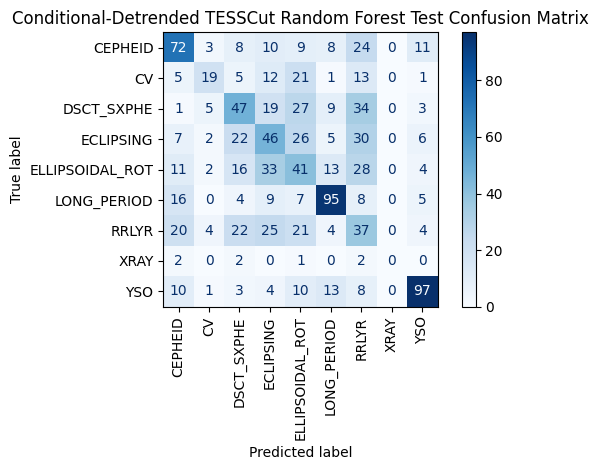

In [20]:

# ============================================================
# Conditional-detrended TESSCut confusion matrix
# ============================================================

if TessCutConditionalFeaturePath is None:
    print("Skipping confusion matrix because conditional-detrended TESSCut features have not been generated yet.")
else:
    from sklearn.metrics import ConfusionMatrixDisplay

    TessCutConditionalLabels = sorted(YTessCutConditionalTest.unique())

    ConfusionMatrixDisplay.from_predictions(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        labels=TessCutConditionalLabels,
        xticks_rotation=90,
        cmap="Blues",
    )

    plt.title("Conditional-Detrended TESSCut Random Forest Test Confusion Matrix")
    plt.tight_layout()
    plt.show()


### Controlled Conditional Detrending Experiment — Results

The comparison holds the modeling sample, train/validation/test assignments, 39-feature schema, Random Forest configuration, and random state fixed.

On the identical 1,093-object held-out test set, conditional detrending increases accuracy from **0.3916 to 0.4154** and balanced accuracy from **0.3403 to 0.3620**. Among the identical 834 TESSCut test objects, accuracy increases from **0.2878 to 0.3201** and balanced accuracy from **0.2447 to 0.2703**.

Conditional detrending therefore produces a measurable but modest improvement under the controlled configuration. The improvement is substantially smaller than the matched provenance performance gaps reported later in the notebook.


## Step 18 — Phase-Folded Morphology Analysis

This experiment tests whether hand-engineered phase-folded shape descriptors add predictive information beyond the existing period, amplitude, and global-variability features. The descriptors quantify binned phase-curve amplitude, local differences, extrema sharpness, skewness, kurtosis, and low-order Fourier structure.

Phase folding uses the estimated Lomb–Scargle best period, so period errors and aliases propagate into the morphology descriptors. The experiment compares matched Random Forest configurations with and without the phase-morphology feature set.


In [21]:

# ============================================================
# Phase-folded morphology feature extraction helpers
# ============================================================

from pathlib import Path
import warnings

try:
    from astropy.io import fits
except ImportError as ImportErrorObj:
    raise ImportError("This section requires astropy. Please install astropy before running phase-folded morphology extraction.") from ImportErrorObj


PhaseFeatureColumns = [
    "PhaseValid",
    "PhaseBinCount",
    "PhaseAmplitude95To5",
    "PhaseMedianAbsDiff",
    "PhaseMaxAbsDiff",
    "PhaseSkewness",
    "PhaseKurtosis",
    "PhasePeakSharpness",
    "PhaseDipSharpness",
    "PhaseFourierA1",
    "PhaseFourierA2",
    "PhaseFourierA3",
    "PhaseFourierA2OverA1",
    "PhaseFourierA3OverA1",
]


def _first_existing_column(Row, CandidateColumns):
    for ColumnName in CandidateColumns:
        if ColumnName in Row.index:
            Value = Row[ColumnName]
            if pd.notna(Value) and str(Value).strip() != "":
                return str(Value)
    return None


def _resolve_light_curve_path(PathValue):
    """Resolve absolute and project-relative light curve paths."""
    if PathValue is None:
        return None

    PathStr = str(PathValue).strip()
    if PathStr == "":
        return None

    Candidate = Path(PathStr)
    if Candidate.exists():
        return Candidate

    ProjectRoots = [
        Project_Root,
        Project_Root / "data_pipeline",
    ]

    for Root in ProjectRoots:
        Candidate = Root / PathStr.lstrip("/")
        if Candidate.exists():
            return Candidate

    return Path(PathStr)


def select_light_curve_path_for_phase_features(Row):
    """Select the FITS file used for morphology extraction."""
    ProvenanceColumn = "Provenance" if "Provenance" in Row.index else "provenance" if "provenance" in Row.index else None
    ProvenanceValue = str(Row[ProvenanceColumn]).strip() if ProvenanceColumn is not None and pd.notna(Row[ProvenanceColumn]) else ""

    HasDetrendedFlag = "detrended" in Row.index
    IsDetrended = False
    if HasDetrendedFlag and pd.notna(Row["detrended"]):
        IsDetrended = str(Row["detrended"]).strip().lower() in ["true", "1", "yes", "y"]

    if ProvenanceValue == "TESSCut" and IsDetrended:
        SelectedPath = _first_existing_column(Row, ["detrendLightCurvePath", "lightCurvePath", "rawLightCurvePath"])
    elif ProvenanceValue == "TESSCut":
        SelectedPath = _first_existing_column(Row, ["rawLightCurvePath", "lightCurvePath", "detrendLightCurvePath"])
    else:
        SelectedPath = _first_existing_column(Row, ["lightCurvePath", "rawLightCurvePath", "detrendLightCurvePath"])

    return _resolve_light_curve_path(SelectedPath)


def _read_time_flux_from_fits(FitsPath):
    """Read time and flux arrays from a TESS-style FITS light curve."""
    if FitsPath is None or not Path(FitsPath).exists():
        return None, None

    FluxColumnPriority = [
        "PDCSAP_FLUX",
        "SAP_FLUX",
        "KSPSAP_FLUX",
        "FLUX",
        "flux",
    ]

    TimeColumnPriority = [
        "TIME",
        "time",
    ]

    try:
        with fits.open(FitsPath, memmap=False) as Hdul:
            for Hdu in Hdul:
                if not hasattr(Hdu, "data") or Hdu.data is None:
                    continue
                Data = Hdu.data
                if not hasattr(Data, "columns"):
                    continue

                ColumnNames = list(Data.columns.names)

                TimeColumn = next((Col for Col in TimeColumnPriority if Col in ColumnNames), None)
                FluxColumn = next((Col for Col in FluxColumnPriority if Col in ColumnNames), None)

                if TimeColumn is None or FluxColumn is None:
                    continue

                Time = np.asarray(Data[TimeColumn], dtype=float)
                Flux = np.asarray(Data[FluxColumn], dtype=float)

                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]

                if len(Time) < 30:
                    return None, None

                return Time, Flux

    except Exception:
        return None, None

    return None, None


def _robust_normalize_flux(Flux):
    Median = np.nanmedian(Flux)
    Mad = np.nanmedian(np.abs(Flux - Median))
    if not np.isfinite(Mad) or Mad <= 0:
        Std = np.nanstd(Flux)
        Scale = Std if np.isfinite(Std) and Std > 0 else 1.0
    else:
        Scale = 1.4826 * Mad

    return (Flux - Median) / Scale


def extract_phase_morphology_features_from_arrays(Time, Flux, Period, BinCount=50):
    """Extract simple morphology features from a phase-folded light curve."""
    Empty = {ColumnName: np.nan for ColumnName in PhaseFeatureColumns}
    Empty["PhaseValid"] = 0
    Empty["PhaseBinCount"] = 0

    if Time is None or Flux is None:
        return Empty

    if Period is None or not np.isfinite(Period) or Period <= 0:
        return Empty

    Mask = np.isfinite(Time) & np.isfinite(Flux)
    Time = Time[Mask]
    Flux = Flux[Mask]

    if len(Time) < 30:
        return Empty

    FluxNorm = _robust_normalize_flux(Flux)
    Phase = np.mod(Time, Period) / Period

    BinEdges = np.linspace(0, 1, BinCount + 1)
    BinIds = np.digitize(Phase, BinEdges) - 1

    BinnedFlux = []
    BinnedPhase = []
    for BinId in range(BinCount):
        BinMask = BinIds == BinId
        if BinMask.sum() >= 3:
            BinnedFlux.append(np.nanmedian(FluxNorm[BinMask]))
            BinnedPhase.append((BinEdges[BinId] + BinEdges[BinId + 1]) / 2)

    BinnedFlux = np.asarray(BinnedFlux, dtype=float)
    BinnedPhase = np.asarray(BinnedPhase, dtype=float)

    ValidMask = np.isfinite(BinnedFlux) & np.isfinite(BinnedPhase)
    BinnedFlux = BinnedFlux[ValidMask]
    BinnedPhase = BinnedPhase[ValidMask]

    if len(BinnedFlux) < 10:
        return Empty

    SortIndex = np.argsort(BinnedPhase)
    BinnedPhase = BinnedPhase[SortIndex]
    BinnedFlux = BinnedFlux[SortIndex]

    ClosedFlux = np.r_[BinnedFlux, BinnedFlux[0]]
    AdjacentDiff = np.diff(ClosedFlux)

    P05, P25, P50, P75, P95 = np.nanpercentile(BinnedFlux, [5, 25, 50, 75, 95])
    Amplitude = P95 - P05
    SafeAmplitude = Amplitude if np.isfinite(Amplitude) and Amplitude > 1e-12 else np.nan

    CenteredFlux = BinnedFlux - np.nanmean(BinnedFlux)
    FluxStd = np.nanstd(CenteredFlux)
    if np.isfinite(FluxStd) and FluxStd > 0:
        Skewness = np.nanmean((CenteredFlux / FluxStd) ** 3)
        Kurtosis = np.nanmean((CenteredFlux / FluxStd) ** 4)
    else:
        Skewness = np.nan
        Kurtosis = np.nan

    FourierAmplitudes = []
    for Harmonic in [1, 2, 3]:
        CosCoeff = np.nanmean(CenteredFlux * np.cos(2 * np.pi * Harmonic * BinnedPhase))
        SinCoeff = np.nanmean(CenteredFlux * np.sin(2 * np.pi * Harmonic * BinnedPhase))
        FourierAmplitudes.append(np.sqrt(CosCoeff ** 2 + SinCoeff ** 2))

    A1, A2, A3 = FourierAmplitudes
    SafeA1 = A1 if np.isfinite(A1) and A1 > 1e-12 else np.nan

    FeatureDict = {
        "PhaseValid": 1,
        "PhaseBinCount": len(BinnedFlux),
        "PhaseAmplitude95To5": Amplitude,
        "PhaseMedianAbsDiff": np.nanmedian(np.abs(AdjacentDiff)),
        "PhaseMaxAbsDiff": np.nanmax(np.abs(AdjacentDiff)),
        "PhaseSkewness": Skewness,
        "PhaseKurtosis": Kurtosis,
        "PhasePeakSharpness": (P95 - P75) / SafeAmplitude,
        "PhaseDipSharpness": (P25 - P05) / SafeAmplitude,
        "PhaseFourierA1": A1,
        "PhaseFourierA2": A2,
        "PhaseFourierA3": A3,
        "PhaseFourierA2OverA1": A2 / SafeA1,
        "PhaseFourierA3OverA1": A3 / SafeA1,
    }

    return FeatureDict


def extract_phase_morphology_features_for_row(Row, PeriodColumn="LsBestPeriod"):
    Period = Row[PeriodColumn] if PeriodColumn in Row.index else np.nan
    FitsPath = select_light_curve_path_for_phase_features(Row)
    Time, Flux = _read_time_flux_from_fits(FitsPath)
    return extract_phase_morphology_features_from_arrays(Time, Flux, Period)


In [22]:

# ============================================================
# Compute or load phase-folded morphology features for each split
# ============================================================

ForceRecomputePhaseFeatures = False

PhaseFeatureCachePaths = {
    "train": OutputDir / "phase_morphology_train.parquet",
    "validation": OutputDir / "phase_morphology_validation.parquet",
    "test": OutputDir / "phase_morphology_test.parquet",
}


def compute_phase_features_for_split(SplitDf, SplitName):
    CachePath = PhaseFeatureCachePaths[SplitName]

    if CachePath.exists() and not ForceRecomputePhaseFeatures:
        CachedDf = pd.read_parquet(CachePath)
        if len(CachedDf) == len(SplitDf) and set(PhaseFeatureColumns).issubset(CachedDf.columns):
            print(f"Loaded cached phase morphology features for {SplitName}: {CachePath}")
            return CachedDf[PhaseFeatureColumns].copy()

        print(f"Cached phase morphology file for {SplitName} is stale; recomputing.")

    FeatureRows = []
    for _, Row in SplitDf.iterrows():
        FeatureRows.append(extract_phase_morphology_features_for_row(Row))

    PhaseDf = pd.DataFrame(FeatureRows)
    PhaseDf = PhaseDf.reindex(columns=PhaseFeatureColumns)

    PhaseDf.to_parquet(CachePath, index=False)
    print(f"Saved phase morphology features for {SplitName}: {CachePath}")

    return PhaseDf


PhaseTrainDf = compute_phase_features_for_split(TrainDf, "train")
PhaseValDf = compute_phase_features_for_split(ValDf, "validation")
PhaseTestDf = compute_phase_features_for_split(TestDf, "test")

print("Phase feature validity rates:")
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "valid_rate": [
        PhaseTrainDf["PhaseValid"].mean(),
        PhaseValDf["PhaseValid"].mean(),
        PhaseTestDf["PhaseValid"].mean(),
    ],
    "row_count": [
        len(PhaseTrainDf),
        len(PhaseValDf),
        len(PhaseTestDf),
    ],
}))


Loaded cached phase morphology features for train: /data/projects/TESS-research/ml_analytics/output/phase_morphology_train.parquet
Loaded cached phase morphology features for validation: /data/projects/TESS-research/ml_analytics/output/phase_morphology_validation.parquet
Loaded cached phase morphology features for test: /data/projects/TESS-research/ml_analytics/output/phase_morphology_test.parquet
Phase feature validity rates:


,split,valid_rate,row_count
0,train,1.0,5096
1,validation,1.0,1092
2,test,1.0,1093


In [23]:

# ============================================================
# Random Forest with phase-folded morphology features
# ============================================================

TrainWithPhaseDf = pd.concat(
    [TrainDf.reset_index(drop=True), PhaseTrainDf.reset_index(drop=True)],
    axis=1,
)

ValWithPhaseDf = pd.concat(
    [ValDf.reset_index(drop=True), PhaseValDf.reset_index(drop=True)],
    axis=1,
)

TestWithPhaseDf = pd.concat(
    [TestDf.reset_index(drop=True), PhaseTestDf.reset_index(drop=True)],
    axis=1,
)

UsablePhaseFeatureColumns = [
    ColumnName for ColumnName in PhaseFeatureColumns
    if ColumnName in TrainWithPhaseDf.columns
    and ColumnName != "PhaseValid"
]

FeatureColumnsWithPhase = FeatureColumns + UsablePhaseFeatureColumns

XTrainPhase = TrainWithPhaseDf[FeatureColumnsWithPhase]
yTrainPhase = TrainWithPhaseDf[TargetColumn]

XValPhase = ValWithPhaseDf[FeatureColumnsWithPhase]
yValPhase = ValWithPhaseDf[TargetColumn]

XTestPhase = TestWithPhaseDf[FeatureColumnsWithPhase]
yTestPhase = TestWithPhaseDf[TargetColumn]

RandomForestWithPhaseModel = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=RandomState,
        n_jobs=-1,
        class_weight="balanced",
    )),
])

RandomForestWithPhaseModel.fit(XTrainPhase, yTrainPhase)

RandomForestWithPhaseTrainPred = RandomForestWithPhaseModel.predict(XTrainPhase)
RandomForestWithPhaseValPred = RandomForestWithPhaseModel.predict(XValPhase)
RandomForestWithPhaseTestPred = RandomForestWithPhaseModel.predict(XTestPhase)

PhaseModelComparisonDf = pd.DataFrame({
    "model": [
        "RF without phase morphology",
        "RF with phase morphology",
    ],
    "validation_accuracy": [
        accuracy_score(yVal, RandomForestValPred),
        accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "validation_balanced_accuracy": [
        balanced_accuracy_score(yVal, RandomForestValPred),
        balanced_accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "test_accuracy": [
        accuracy_score(yTest, RandomForestTestPred),
        accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
    "test_balanced_accuracy": [
        balanced_accuracy_score(yTest, RandomForestTestPred),
        balanced_accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
})

print("Random Forest comparison with and without phase-folded morphology features:")
display(PhaseModelComparisonDf)


Random Forest comparison with and without phase-folded morphology features:


,model,validation_accuracy,validation_balanced_accuracy,test_accuracy,test_balanced_accuracy
0,RF without phase morphology,0.409341,0.397911,0.391583,0.340308
1,RF with phase morphology,0.412088,0.389196,0.408966,0.355865


Random Forest with phase-folded morphology — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.43      0.51      0.47       145
             CV       0.53      0.23      0.32        77
     DSCT_SXPHE       0.35      0.27      0.30       145
      ECLIPSING       0.25      0.29      0.27       144
ELLIPSOIDAL_ROT       0.30      0.30      0.30       148
    LONG_PERIOD       0.69      0.64      0.66       144
          RRLYR       0.19      0.27      0.22       137
           XRAY       0.00      0.00      0.00         7
            YSO       0.74      0.69      0.71       146

       accuracy                           0.41      1093
      macro avg       0.39      0.36      0.36      1093
   weighted avg       0.43      0.41      0.41      1093



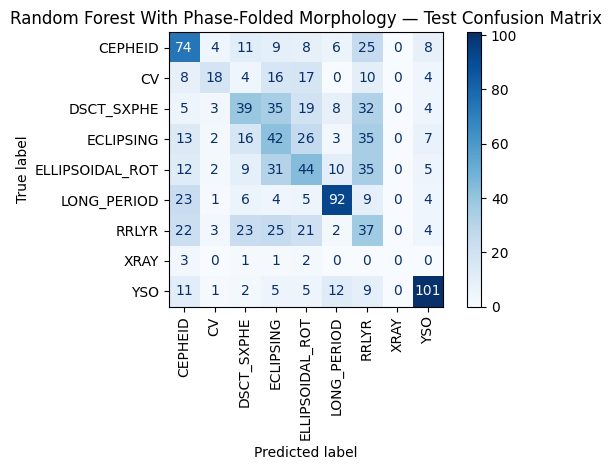

In [24]:

# ============================================================
# Phase-folded morphology model diagnostics
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

print("Random Forest with phase-folded morphology — test classification report:")
print(classification_report(yTestPhase, RandomForestWithPhaseTestPred, zero_division=0))

PhaseLabels = sorted(yTestPhase.unique())

ConfusionMatrixDisplay.from_predictions(
    yTestPhase,
    RandomForestWithPhaseTestPred,
    labels=PhaseLabels,
    xticks_rotation=90,
    cmap="Blues",
)

plt.title("Random Forest With Phase-Folded Morphology — Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [25]:

# ============================================================
# Feature importance for phase-folded morphology model
# ============================================================

RfWithPhaseClassifier = RandomForestWithPhaseModel.named_steps["model"]

PhaseImportanceDf = pd.DataFrame({
    "Feature": FeatureColumnsWithPhase,
    "Importance": RfWithPhaseClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

print("Top 30 Random Forest feature importances with phase morphology features:")
display(PhaseImportanceDf.head(30))

print("Phase morphology features only:")
display(
    PhaseImportanceDf[PhaseImportanceDf["Feature"].isin(UsablePhaseFeatureColumns)]
    .sort_values("Importance", ascending=False)
)


Top 30 Random Forest feature importances with phase morphology features:


,Feature,Importance
19,EtaVonNeumann,0.036406
2,OriginalFluxStd,0.031490
28,LsPeriod3,0.030504
20,MaxAbsSlope,0.029351
24,LsBestPeriod,0.028669
21,MedianAbsSuccessiveDiff,0.027665
27,LsPeriod2,0.027208
46,PhaseDipSharpness,0.026321
13,FluxAmplitude,0.024959
41,PhaseMedianAbsDiff,0.024816


Phase morphology features only:


,Feature,Importance
46,PhaseDipSharpness,0.026321
41,PhaseMedianAbsDiff,0.024816
40,PhaseAmplitude95To5,0.022759
42,PhaseMaxAbsDiff,0.022184
47,PhaseFourierA1,0.021488
45,PhasePeakSharpness,0.020478
43,PhaseSkewness,0.019765
44,PhaseKurtosis,0.019392
49,PhaseFourierA3,0.018549
48,PhaseFourierA2,0.018247


### Phase-Folded Morphology Results

The added phase-folded features produce a limited and mixed effect. Validation accuracy and balanced accuracy increase modestly. Test accuracy increases, while test balanced accuracy decreases slightly. Feature extraction succeeds for approximately **98.4%** of rows.

The tested morphology descriptors therefore do not provide a robust improvement across variable-star families.


## Phase-Folded Morphology Analysis Conclusion

Adding the tested phase-folded morphology features improves ordinary accuracy but does not improve balanced held-out performance. The experiment establishes limited additional predictive benefit rather than a robust across-class improvement. This effect is smaller and less consistent than the provenance-associated performance differences measured in the controlled comparisons.


## Step 19 — Provenance-Specific Feature Importance Comparison

This section trains separate SPOC-only, QLP-only, and TESSCut-only Random Forest models and compares impurity-based and permutation feature importance. The analysis measures provenance-associated differences in model dependence.

Because the provenance subsets differ in sample size and family composition, these unmatched models do not isolate pipeline causality. The matched-star experiments later in the notebook provide the controlled provenance comparison.


### Provenance Distribution and Family Composition

The executed dataset contains **509 SPOC**, **1,353 QLP**, and **5,419 TESSCut** objects, for **7,281** total rows. Family composition differs across provenance sources, motivating the matched-star controls later in the notebook.


In [26]:
# ============================================================
# Provenance distribution and family-by-provenance composition
# ============================================================

PossibleProvenanceColumnsForDistribution = ["Provenance", "provenance", "Source", "source"]

ProvenanceDistributionColumn = None
for CandidateColumn in PossibleProvenanceColumnsForDistribution:
    if CandidateColumn in ModelDf.columns:
        ProvenanceDistributionColumn = CandidateColumn
        break

if ProvenanceDistributionColumn is None:
    raise KeyError(
        "Could not find a provenance/source column for the distribution analysis. "
        f"Tried: {PossibleProvenanceColumnsForDistribution}"
    )

# Normalize only display labels so equivalent capitalization is grouped together.
def normalize_provenance_label(value):
    if pd.isna(value):
        return "Missing"

    text = str(value).strip()
    upper = text.upper()

    if upper == "SPOC":
        return "SPOC"
    if upper == "QLP":
        return "QLP"
    if upper in {"TESSCUT", "TESS CUT"}:
        return "TESSCut"

    return text

ProvenanceDistributionDf = ModelDf.copy()
ProvenanceDistributionDf["ProvenanceNormalized"] = (
    ProvenanceDistributionDf[ProvenanceDistributionColumn]
    .map(normalize_provenance_label)
)

ProvenanceCountDf = (
    ProvenanceDistributionDf["ProvenanceNormalized"]
    .value_counts(dropna=False)
    .rename_axis("Provenance")
    .reset_index(name="ObjectCount")
)
ProvenanceCountDf["Percentage"] = (
    100.0 * ProvenanceCountDf["ObjectCount"] / ProvenanceCountDf["ObjectCount"].sum()
)

print("Overall provenance distribution:")
display(
    ProvenanceCountDf.style.format({
        "ObjectCount": "{:,}",
        "Percentage": "{:.2f}%",
    })
)

FamilyByProvenanceCountDf = pd.crosstab(
    ProvenanceDistributionDf[TargetColumn],
    ProvenanceDistributionDf["ProvenanceNormalized"],
    margins=True,
    margins_name="All",
)

print("Family-by-provenance object counts:")
display(FamilyByProvenanceCountDf)

FamilyWithinProvenancePercentDf = pd.crosstab(
    ProvenanceDistributionDf[TargetColumn],
    ProvenanceDistributionDf["ProvenanceNormalized"],
    normalize="columns",
) * 100.0

print("Family distribution within each provenance source:")
display(FamilyWithinProvenancePercentDf.style.format("{:.2f}%"))

ProvenanceCountDf.to_csv(
    OutputDir / "provenance_distribution.csv",
    index=False,
)
FamilyByProvenanceCountDf.to_csv(
    OutputDir / "family_by_provenance_counts.csv",
)
FamilyWithinProvenancePercentDf.to_csv(
    OutputDir / "family_within_provenance_percent.csv",
)


Overall provenance distribution:


,Provenance,ObjectCount,Percentage
0,TESSCut,"5,419",74.43%
1,QLP,"1,353",18.58%
2,SPOC,509,6.99%


Family-by-provenance object counts:


ProvenanceNormalized,QLP,SPOC,TESSCut,All
family,,,,
CEPHEID,233,64,665,962
CV,2,114,400,516
DSCT_SXPHE,211,51,706,968
ECLIPSING,110,14,832,956
ELLIPSOIDAL_ROT,151,29,802,982
LONG_PERIOD,487,118,354,959
RRLYR,17,5,895,917
XRAY,10,20,21,51
YSO,132,94,744,970


Family distribution within each provenance source:


ProvenanceNormalized,QLP,SPOC,TESSCut
family,,,
CEPHEID,17.22%,12.57%,12.27%
CV,0.15%,22.40%,7.38%
DSCT_SXPHE,15.59%,10.02%,13.03%
ECLIPSING,8.13%,2.75%,15.35%
ELLIPSOIDAL_ROT,11.16%,5.70%,14.80%
LONG_PERIOD,35.99%,23.18%,6.53%
RRLYR,1.26%,0.98%,16.52%
XRAY,0.74%,3.93%,0.39%
YSO,9.76%,18.47%,13.73%


### Predictor-set consistency for provenance-specific models

The separate phase-folded morphology augmentation experiment is retained as a diagnostic, but it did not improve the principal classifier. Therefore, the provenance-specific Random Forest models below use the same final filtered predictor set (`FeatureColumns`) as the principal Random Forest and the matched-star provenance experiments. This avoids changing the feature space between provenance analyses and keeps performance and feature-importance comparisons directly comparable.


In [27]:

# ============================================================
# Provenance-specific Random Forest models + feature importance comparison
# ============================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Use the same final predictor set as the principal and matched analyses
# ------------------------------------------------------------
# The separate phase-morphology augmentation experiment did not improve the
# principal model, so provenance-specific comparisons use the same filtered
# FeatureColumns set as the main Random Forest and matched-star experiments.
# This keeps the provenance comparisons controlled and directly comparable.
ProvenanceComparisonDfForTraining = ModelDf.copy()
ProvenanceComparisonFeatureColumns = list(FeatureColumns)

print(
    "Using the same filtered predictor set as the principal and matched analyses: "
    f"{len(ProvenanceComparisonFeatureColumns)} features."
)

assert ProvenanceComparisonFeatureColumns == list(FeatureColumns), (
    "Provenance-specific models must use the same FeatureColumns as the "
    "principal and matched-star analyses."
)


# ------------------------------------------------------------
# 2. Identify provenance column
# ------------------------------------------------------------
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]

ProvenanceColumn = None
for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in ProvenanceComparisonDfForTraining.columns:
        ProvenanceColumn = CandidateColumn
        break

if ProvenanceColumn is None:
    raise KeyError(
        "Could not find a provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

print(f"Using provenance column: {ProvenanceColumn}")


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def train_provenance_rf_model(
    InputDf,
    ProvenanceName,
    FeatureColumnsForModel,
    TargetColumnName,
    ProvenanceColumnName,
    random_state=42,
    test_size=0.30,
):
    """Train a provenance-specific RF model and return model/split/results."""

    SourceDf = InputDf[InputDf[ProvenanceColumnName] == ProvenanceName].copy()

    if SourceDf.empty:
        raise ValueError(f"No rows found for provenance: {ProvenanceName}")

    ClassCounts = SourceDf[TargetColumnName].value_counts().sort_index()

    # Stratified splitting requires at least two examples per class.
    KeepClasses = ClassCounts[ClassCounts >= 2].index
    DroppedClasses = ClassCounts[ClassCounts < 2]

    if len(DroppedClasses) > 0:
        print(f"\n{ProvenanceName}: dropping classes with fewer than 2 samples before stratified split:")
        display(DroppedClasses)

    SourceDf = SourceDf[SourceDf[TargetColumnName].isin(KeepClasses)].copy()

    if SourceDf[TargetColumnName].nunique() < 2:
        raise ValueError(
            f"{ProvenanceName}: fewer than two classes remain after filtering; "
            "cannot train classifier."
        )

    X = SourceDf[FeatureColumnsForModel]
    y = SourceDf[TargetColumnName]

    XTrainProv, XTestProv, yTrainProv, yTestProv = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    Model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state,
            )),
        ]
    )

    Model.fit(XTrainProv, yTrainProv)

    TrainPred = Model.predict(XTrainProv)
    TestPred = Model.predict(XTestProv)

    AccuracyDf = pd.DataFrame([
        {
            "Provenance": ProvenanceName,
            "split": "train",
            "accuracy": accuracy_score(yTrainProv, TrainPred),
            "balanced_accuracy": balanced_accuracy_score(yTrainProv, TrainPred),
            "sample_count": len(yTrainProv),
        },
        {
            "Provenance": ProvenanceName,
            "split": "test",
            "accuracy": accuracy_score(yTestProv, TestPred),
            "balanced_accuracy": balanced_accuracy_score(yTestProv, TestPred),
            "sample_count": len(yTestProv),
        },
    ])

    return {
        "model": Model,
        "x_train": XTrainProv,
        "x_test": XTestProv,
        "y_train": yTrainProv,
        "y_test": yTestProv,
        "test_pred": TestPred,
        "accuracy_df": AccuracyDf,
        "class_counts": ClassCounts,
    }


def build_rf_feature_importance_df(model, feature_columns, provenance_name):
    """Return Random Forest built-in feature importance for one provenance-specific model."""
    RfEstimator = model.named_steps["model"] if hasattr(model, "named_steps") else model

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "RFImportance": RfEstimator.feature_importances_
        })
        .sort_values("RFImportance", ascending=False)
        .reset_index(drop=True)
    )


def build_permutation_importance_df(
    model,
    x_test,
    y_test,
    feature_columns,
    provenance_name,
    scoring="balanced_accuracy",
    n_repeats=50,
    random_state=42
):
    """Return permutation importance for one provenance-specific model."""
    print(f"Permutation importance repeats: {n_repeats}")
    perm_result = permutation_importance(
        model,
        x_test,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "PermutationImportanceMean": perm_result.importances_mean,
            "PermutationImportanceStd": perm_result.importances_std
        })
        .sort_values("PermutationImportanceMean", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 4. Train provenance-specific RF models
# ------------------------------------------------------------

SpocResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "SPOC",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

QlpResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "QLP",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

TessCutResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "TESSCut",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

# Expose variables using names expected by the later comparison logic.
SpocRfModel = SpocResults["model"]
QlpRfModel = QlpResults["model"]
TessCutRfModel = TessCutResults["model"]

XSpocTest = SpocResults["x_test"]
YSpocTest = SpocResults["y_test"]

XQlpTest = QlpResults["x_test"]
YQlpTest = QlpResults["y_test"]

XTessCutTest = TessCutResults["x_test"]
YTessCutTest = TessCutResults["y_test"]

ProvenanceSpecificAccuracyDf = pd.concat(
    [
        SpocResults["accuracy_df"],
        QlpResults["accuracy_df"],
        TessCutResults["accuracy_df"],
    ],
    ignore_index=True,
)

print("Provenance-specific Random Forest performance:")
display(ProvenanceSpecificAccuracyDf)


# ------------------------------------------------------------
# 5. RF built-in feature importance
# ------------------------------------------------------------

SpocFeatureImportanceDf = build_rf_feature_importance_df(
    SpocRfModel,
    ProvenanceComparisonFeatureColumns,
    "SPOC"
)

QlpFeatureImportanceDf = build_rf_feature_importance_df(
    QlpRfModel,
    ProvenanceComparisonFeatureColumns,
    "QLP"
)

TessCutFeatureImportanceDf = build_rf_feature_importance_df(
    TessCutRfModel,
    ProvenanceComparisonFeatureColumns,
    "TESSCut"
)

ProvenanceFeatureImportanceDf = pd.concat(
    [SpocFeatureImportanceDf, QlpFeatureImportanceDf, TessCutFeatureImportanceDf],
    ignore_index=True
)

print("Top RF built-in feature importances by provenance:")
display(
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Permutation importance
# ------------------------------------------------------------

SpocPermutationImportanceDf = build_permutation_importance_df(
    SpocRfModel,
    XSpocTest,
    YSpocTest,
    ProvenanceComparisonFeatureColumns,
    "SPOC",
    random_state=RandomState,
)

QlpPermutationImportanceDf = build_permutation_importance_df(
    QlpRfModel,
    XQlpTest,
    YQlpTest,
    ProvenanceComparisonFeatureColumns,
    "QLP",
    random_state=RandomState,
)

TessCutPermutationImportanceDf = build_permutation_importance_df(
    TessCutRfModel,
    XTessCutTest,
    YTessCutTest,
    ProvenanceComparisonFeatureColumns,
    "TESSCut",
    random_state=RandomState,
)

ProvenancePermutationImportanceDf = pd.concat(
    [SpocPermutationImportanceDf, QlpPermutationImportanceDf, TessCutPermutationImportanceDf],
    ignore_index=True
)

print("Top permutation importances by provenance:")
display(
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Side-by-side summaries
# ------------------------------------------------------------

TopN = 10

TopRfImportanceSummaryDf = (
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

TopPermutationImportanceSummaryDf = (
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

print("Top RF built-in feature importance comparison:")
display(TopRfImportanceSummaryDf)

print("Top permutation importance comparison:")
display(TopPermutationImportanceSummaryDf)


Using the same filtered predictor set as the principal and matched analyses: 39 features.
Using provenance column: Provenance
Provenance-specific Random Forest performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,SPOC,train,1.000000,1.000000,356
1,SPOC,test,0.732026,0.553974,153
2,QLP,train,1.000000,1.000000,947
3,QLP,test,0.684729,0.444413,406
4,TESSCut,train,0.999736,0.999823,3793
5,TESSCut,test,0.308733,0.258481,1626


Top RF built-in feature importances by provenance:


,Provenance,Feature,RFImportance
0,SPOC,OriginalFluxStd,0.080315
1,SPOC,LsBestPeriod,0.067719
2,SPOC,LsPeriod2,0.063382
3,SPOC,LsPeriod3,0.060048
4,SPOC,MedianAbsSuccessiveDiff,0.043401
5,SPOC,EtaVonNeumann,0.041640
6,SPOC,FluxMad,0.038725
7,SPOC,FluxP95,0.036645
8,SPOC,FluxIqr,0.036336
9,SPOC,MaxAbsSlope,0.034673


Permutation importance repeats: 50
Permutation importance repeats: 50
Permutation importance repeats: 50
Top permutation importances by provenance:


,Provenance,Feature,PermutationImportanceMean,PermutationImportanceStd
0,SPOC,OriginalFluxStd,0.046417,0.023500
1,SPOC,MaxAbsSlope,0.015189,0.005559
2,SPOC,FluxIqr,0.013834,0.006093
3,SPOC,FractionBeyond1Std,0.009665,0.006847
4,SPOC,EtaVonNeumann,0.008423,0.009229
5,SPOC,PhasePeakPhase,0.006511,0.003941
6,SPOC,LsPeakPowerGap12,0.005899,0.005070
7,SPOC,LsPowerRatio21,0.004031,0.003156
8,SPOC,MedianCadenceDays,0.003810,0.002407
9,SPOC,PhaseCurveStd,0.003050,0.008398


Top RF built-in feature importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,LsPeriod2,OriginalFluxStd,EtaVonNeumann
2,LsBestPeriod,LsBestPeriod,FluxAmplitude
3,LsPeriod3,LsPeriod2,MaxAbsSlope
4,TailAsymmetry,LsPeriod3,TimeSpanDays
5,TailRatio,MedianAbsSuccessiveDiff,FractionBeyond1Std
6,OriginalFluxStd,EtaVonNeumann,CadenceCount
7,FluxP05,FluxMad,OriginalFluxStd
8,LsMaxPower,FluxP95,TailRatio
9,FluxSkewness,FluxIqr,FractionBeyond2Std


Top permutation importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,MedianAbsSuccessiveDiff,OriginalFluxStd,FluxAmplitude
2,FluxIqr,MaxAbsSlope,FluxP95
3,FluxP90,FluxIqr,CadenceCount
4,OriginalFluxStd,FractionBeyond1Std,FluxP05
5,TailRatio,EtaVonNeumann,EtaVonNeumann
6,EtaVonNeumann,PhasePeakPhase,OriginalFluxStd
7,FluxMad,LsPeakPowerGap12,TailRatio
8,TailAsymmetry,LsPowerRatio21,MedianAbsSuccessiveDiff
9,FluxP05,MedianCadenceDays,TimeSpanDays


### Provenance-Specific Confusion Matrices

The following confusion matrices use the held-out test predictions from the separately trained SPOC-only, QLP-only, and TESSCut-only Random Forest models.

They show which variable-star families are confused within each provenance source and complement the overall accuracy and balanced-accuracy measurements.

SPOC-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.88      0.74      0.80        19
             CV       0.72      0.82      0.77        34
     DSCT_SXPHE       0.82      0.93      0.88        15
      ECLIPSING       1.00      0.25      0.40         4
ELLIPSOIDAL_ROT       1.00      0.11      0.20         9
    LONG_PERIOD       0.75      0.92      0.82        36
          RRLYR       0.33      0.50      0.40         2
           XRAY       0.00      0.00      0.00         6
            YSO       0.65      0.71      0.68        28

       accuracy                           0.73       153
      macro avg       0.68      0.55      0.55       153
   weighted avg       0.73      0.73      0.70       153



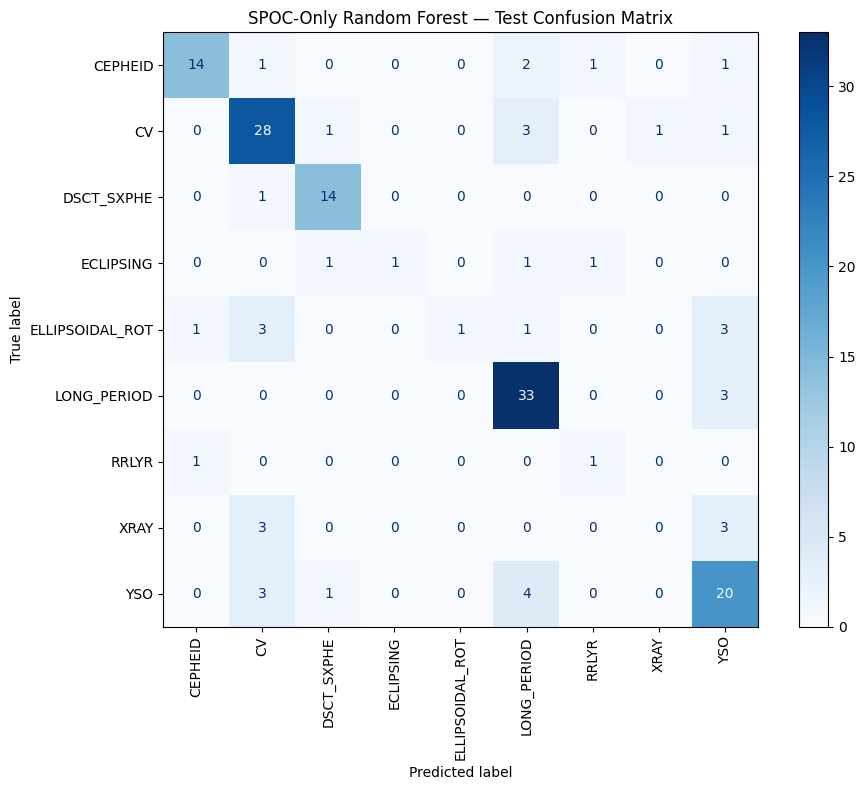

QLP-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.80      0.74      0.77        70
             CV       0.00      0.00      0.00         1
     DSCT_SXPHE       0.74      0.67      0.70        63
      ECLIPSING       0.85      0.52      0.64        33
ELLIPSOIDAL_ROT       0.51      0.58      0.54        45
    LONG_PERIOD       0.66      0.90      0.76       146
          RRLYR       1.00      0.40      0.57         5
           XRAY       0.00      0.00      0.00         3
            YSO       0.67      0.20      0.31        40

       accuracy                           0.68       406
      macro avg       0.58      0.44      0.48       406
   weighted avg       0.69      0.68      0.66       406



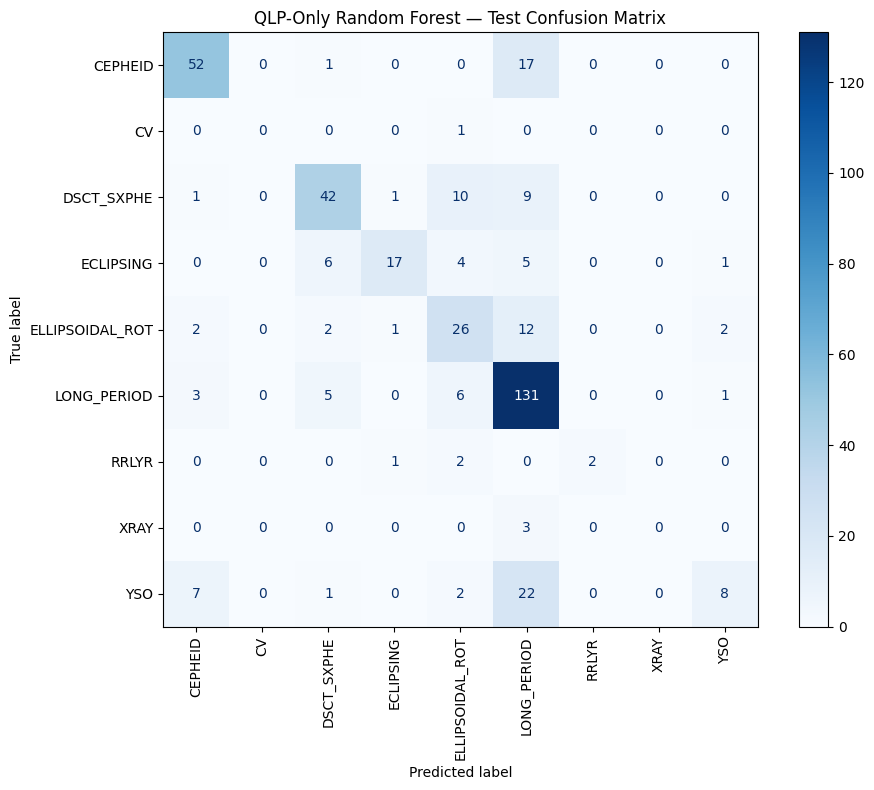

TESSCut-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.26      0.29      0.28       199
             CV       0.00      0.00      0.00       120
     DSCT_SXPHE       0.18      0.16      0.17       212
      ECLIPSING       0.23      0.26      0.24       250
ELLIPSOIDAL_ROT       0.28      0.32      0.29       241
    LONG_PERIOD       0.48      0.29      0.36       106
          RRLYR       0.21      0.29      0.25       269
           XRAY       0.00      0.00      0.00         6
            YSO       0.77      0.71      0.74       223

       accuracy                           0.31      1626
      macro avg       0.27      0.26      0.26      1626
   weighted avg       0.30      0.31      0.30      1626



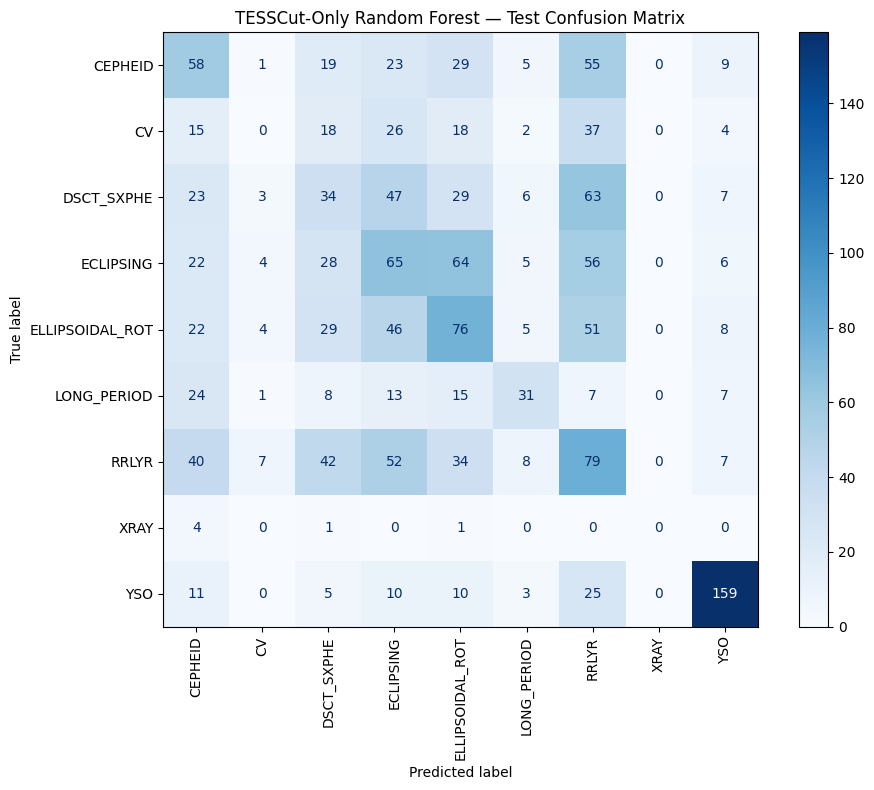

Per-family test metrics by provenance:


,Provenance,Family,Precision,Recall,F1Score,Support
0,SPOC,CEPHEID,0.875,0.737,0.800,19
1,SPOC,CV,0.718,0.824,0.767,34
2,SPOC,DSCT_SXPHE,0.824,0.933,0.875,15
3,SPOC,ECLIPSING,1.000,0.250,0.400,4
4,SPOC,ELLIPSOIDAL_ROT,1.000,0.111,0.200,9
5,SPOC,LONG_PERIOD,0.750,0.917,0.825,36
6,SPOC,RRLYR,0.333,0.500,0.400,2
7,SPOC,XRAY,0.000,0.000,0.000,6
8,SPOC,YSO,0.645,0.714,0.678,28
9,QLP,CEPHEID,0.800,0.743,0.770,70


In [28]:
# ============================================================
# Provenance-specific test confusion matrices
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ProvenanceConfusionInputs = [
    ("SPOC", SpocResults["y_test"], SpocResults["test_pred"]),
    ("QLP", QlpResults["y_test"], QlpResults["test_pred"]),
    ("TESSCut", TessCutResults["y_test"], TessCutResults["test_pred"]),
]

ProvenanceClassificationReportRows = []

for ProvenanceName, yTrueProv, yPredProv in ProvenanceConfusionInputs:
    LabelsProv = sorted(pd.Series(yTrueProv).dropna().unique())

    print(f"{ProvenanceName}-only Random Forest — test classification report:")
    print(classification_report(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        zero_division=0,
    ))

    Fig, Ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        xticks_rotation=90,
        cmap="Blues",
        values_format="d",
        ax=Ax,
    )
    Ax.set_title(f"{ProvenanceName}-Only Random Forest — Test Confusion Matrix")
    Fig.tight_layout()
    plt.show()
    plt.close(Fig)

    ReportDict = classification_report(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        output_dict=True,
        zero_division=0,
    )

    for FamilyName in LabelsProv:
        FamilyMetrics = ReportDict.get(FamilyName, {})
        ProvenanceClassificationReportRows.append({
            "Provenance": ProvenanceName,
            "Family": FamilyName,
            "Precision": FamilyMetrics.get("precision", np.nan),
            "Recall": FamilyMetrics.get("recall", np.nan),
            "F1Score": FamilyMetrics.get("f1-score", np.nan),
            "Support": FamilyMetrics.get("support", np.nan),
        })

ProvenanceClassificationReportDf = pd.DataFrame(ProvenanceClassificationReportRows)

print("Per-family test metrics by provenance:")
display(
    ProvenanceClassificationReportDf.style.format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1Score": "{:.3f}",
        "Support": "{:.0f}",
    })
)

ProvenanceClassificationReportDf.to_csv(
    OutputDir / "provenance_specific_test_classification_metrics.csv",
    index=False,
)


### Feature Category Comparison

Predictors are grouped into periodicity/Lomb–Scargle structure, phase-folded morphology, amplitude, flux distribution, local variability/stochasticity, and observation quality/cadence. Category totals summarize the types of information contributing to each provenance-specific model while reducing sensitivity to individual correlated-feature rankings.


In [29]:

# ============================================================
# Feature category importance comparison
# ============================================================

def categorize_feature(feature_name):
    """Map a feature name into a broad astrophysical/observational category."""
    f = str(feature_name)

    if f.startswith("Phase"):
        return "Phase-folded morphology"

    if f.startswith("Ls") or "Frequency" in f or "Period" in f or "FalseAlarm" in f:
        return "Periodicity / LS structure"

    if "Amplitude" in f:
        return "Amplitude / extrema"

    if (
        "Skewness" in f or
        "Kurtosis" in f or
        "Tail" in f or
        "P05" in f or
        "P10" in f or
        "P50" in f or
        "P90" in f or
        "P95" in f
    ):
        return "Flux distribution / shape"

    if (
        "EtaVonNeumann" in f or
        "SuccessiveDiff" in f or
        "MaxAbsSlope" in f or
        "Slope" in f or
        "Smoothness" in f
    ):
        return "Local variability / stochasticity"

    if (
        "Cadence" in f or
        "TimeSpan" in f or
        "Quality" in f or
        "Snr" in f or
        "SNR" in f or
        "LowSnr" in f
    ):
        return "Observation quality / cadence"

    if "FluxStd" in f or "Std" in f:
        return "Flux scatter / noise"

    return "Other"


CategoryRfImportanceDf = (
    ProvenanceFeatureImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["RFImportance"]
    .sum()
    .sort_values(["Provenance", "RFImportance"], ascending=[True, False])
)

CategoryRfImportancePivotDf = (
    CategoryRfImportanceDf
    .pivot(index="Category", columns="Provenance", values="RFImportance")
    .fillna(0)
)

print("RF built-in importance by feature category:")
display(CategoryRfImportancePivotDf)


CategoryPermutationImportanceDf = (
    ProvenancePermutationImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["PermutationImportanceMean"]
    .sum()
    .sort_values(["Provenance", "PermutationImportanceMean"], ascending=[True, False])
)

CategoryPermutationImportancePivotDf = (
    CategoryPermutationImportanceDf
    .pivot(index="Category", columns="Provenance", values="PermutationImportanceMean")
    .fillna(0)
)

print("Permutation importance by feature category:")
display(CategoryPermutationImportancePivotDf)


ProvenanceFeatureImportanceDf.to_csv(OutputDir / "provenance_rf_feature_importance.csv", index=False)
ProvenancePermutationImportanceDf.to_csv(OutputDir / "provenance_permutation_importance.csv", index=False)
CategoryRfImportancePivotDf.to_csv(OutputDir / "provenance_rf_feature_category_importance.csv")
CategoryPermutationImportancePivotDf.to_csv(OutputDir / "provenance_permutation_feature_category_importance.csv")

print("Saved provenance feature-importance comparison outputs to:")
print(OutputDir)


RF built-in importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.045763,0.051579,0.068204
Flux distribution / shape,0.240463,0.182412,0.203012
Flux scatter / noise,0.082666,0.128375,0.096346
Local variability / stochasticity,0.081275,0.119714,0.112271
Observation quality / cadence,0.049212,0.053344,0.070531
Other,0.059790,0.075220,0.058507
Periodicity / LS structure,0.346460,0.326777,0.275756
Phase-folded morphology,0.094371,0.062579,0.115372


Permutation importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.001753,-0.002698,0.002978
Flux distribution / shape,0.063078,-0.026247,0.006771
Flux scatter / noise,0.023521,0.057640,0.005713
Local variability / stochasticity,0.036410,0.026469,0.007505
Observation quality / cadence,0.006927,0.001053,0.007364
Other,0.030306,0.009571,0.002982
Periodicity / LS structure,0.048671,-0.049187,-0.039716
Phase-folded morphology,0.007157,0.013869,-0.002454


Saved provenance feature-importance comparison outputs to:
/data/projects/TESS-research/ml_analytics/output


### Provenance-Specific Feature Importance Results

The separately trained provenance models exhibit different feature-importance structures. For impurity-based importance, periodicity/Lomb–Scargle structure contributes **0.327 for SPOC**, **0.346 for QLP**, and **0.276 for TESSCut**. TESSCut assigns relatively more importance to phase-folded morphology and observation-quality/cadence features than SPOC or QLP.

These results establish provenance-associated differences in model dependence. Because the unmatched subsets differ in sample size and family composition, they are not treated as an isolated causal estimate of pipeline effects.


## Matched-star performance and permutation-importance definition

The matched-star experiments compare identical star sets under alternative light-curve provenance while holding labels, predictor definitions, Random Forest configuration, and star-level train/test assignments fixed.

- SPOC vs. TESSCut: test accuracy **0.763 vs. 0.632**; balanced accuracy **0.571 vs. 0.387**.
- QLP vs. TESSCut: test accuracy **0.681 vs. 0.518**; balanced accuracy **0.417 vs. 0.265**.

Permutation importance is computed on held-out test data using balanced accuracy and 50 repeats per feature. Rank correlations quantify differences in model dependence rather than exact astrophysical rankings.


In [30]:

# ============================================================
# Step 19 Diagnostic: OriginalFluxStd and OriginalFluxSnr in SPOC
# ============================================================

DiagnosticFeatures = [
    col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
    if col in globals().get("ProvenanceComparisonDfForTraining", ModelDf).columns
]

if len(DiagnosticFeatures) == 0:
    raise KeyError(
        "Neither OriginalFluxStd nor OriginalFluxSnr exists in the current dataframe."
    )

# Use the final dataframe from Step 18 if available; otherwise fall back to ModelDf.
DiagnosticBaseDf = globals().get("ProvenanceComparisonDfForTraining", ModelDf).copy()

# Identify provenance column robustly.
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]
DiagnosticProvenanceColumn = None

for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in DiagnosticBaseDf.columns:
        DiagnosticProvenanceColumn = CandidateColumn
        break

if DiagnosticProvenanceColumn is None:
    raise KeyError(
        "Could not find provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

SpocDiagnosticDf = DiagnosticBaseDf[
    DiagnosticBaseDf[DiagnosticProvenanceColumn] == "SPOC"
].copy()

print(f"SPOC diagnostic row count: {len(SpocDiagnosticDf)}")
print(f"Using provenance column: {DiagnosticProvenanceColumn}")
print(f"Diagnostic features available: {DiagnosticFeatures}")


# ------------------------------------------------------------
# 1. Distribution of OriginalFluxStd / OriginalFluxSnr by class
# ------------------------------------------------------------

SpocFeatureByClassDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .agg(["count", "mean", "median", "std"])
)

print("OriginalFluxStd / OriginalFluxSnr by class within SPOC:")
display(SpocFeatureByClassDf)


# ------------------------------------------------------------
# 2. Correct-vs-incorrect diagnostic if SPOC model variables exist
# ------------------------------------------------------------

RequiredSpocObjects = ["SpocRfModel", "XSpocTest", "YSpocTest"]
MissingSpocObjects = [name for name in RequiredSpocObjects if name not in globals()]

if MissingSpocObjects:
    print(
        "Skipping correct-vs-incorrect SPOC prediction diagnostic because "
        f"these objects are missing: {MissingSpocObjects}"
    )
else:
    SpocTestPredictionDf = XSpocTest.copy()
    SpocTestPredictionDf[TargetColumn] = YSpocTest
    SpocTestPredictionDf["Prediction"] = SpocRfModel.predict(XSpocTest)
    SpocTestPredictionDf["Correct"] = (
        SpocTestPredictionDf[TargetColumn] == SpocTestPredictionDf["Prediction"]
    )

    CorrectComparisonFeatures = [
        col for col in DiagnosticFeatures
        if col in SpocTestPredictionDf.columns
    ]

    if CorrectComparisonFeatures:
        SpocCorrectVsIncorrectDf = (
            SpocTestPredictionDf
            .groupby("Correct")[CorrectComparisonFeatures]
            .agg(["count", "mean", "median", "std"])
        )

        print("SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:")
        display(SpocCorrectVsIncorrectDf)
    else:
        print("Diagnostic features are not present in XSpocTest; skipping correct-vs-incorrect comparison.")


# ------------------------------------------------------------
# 3. Correlation with related amplitude / quality / variability features
# ------------------------------------------------------------

CandidateCorrelationFeatures = [
    "OriginalFluxStd",
    "OriginalFluxSnr",
    "FluxAmplitude",
    "FluxPercentAmplitude95To5",
    "PhaseAmplitude95To5",
    "EtaVonNeumann",
    "MedianAbsSuccessiveDiff",
    "LsMaxPower",
    "LsFalseAlarmProbability",
    "CadenceCount",
    "TimeSpanDays",
]

AvailableCorrelationFeatures = [
    col for col in CandidateCorrelationFeatures
    if col in SpocDiagnosticDf.columns
]

if len(AvailableCorrelationFeatures) >= 2:
    SpocCorrelationDf = SpocDiagnosticDf[AvailableCorrelationFeatures].corr(
        method="spearman"
    )

    print("Spearman correlation among SPOC diagnostic / variability / quality features:")
    display(SpocCorrelationDf)

    ImportantCorrelationRows = [
        col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
        if col in SpocCorrelationDf.index
    ]

    if ImportantCorrelationRows:
        print("Correlations involving OriginalFluxStd / OriginalFluxSnr:")
        display(
            SpocCorrelationDf
            .loc[ImportantCorrelationRows]
            .T
            .sort_values(ImportantCorrelationRows[0], ascending=False)
        )
else:
    print("Not enough related features available for correlation analysis.")


# ------------------------------------------------------------
# 4. Class-level median diagnostic features and sample counts
# ------------------------------------------------------------

SpocClassSupportDf = (
    SpocDiagnosticDf[TargetColumn]
    .value_counts()
    .rename_axis(TargetColumn)
    .reset_index(name="SpocSampleCount")
)

SpocClassFeatureSummaryDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .median()
    .reset_index()
    .merge(SpocClassSupportDf, on=TargetColumn, how="left")
    .sort_values("SpocSampleCount", ascending=False)
)

print("SPOC class-level median diagnostic features and sample count:")
display(SpocClassFeatureSummaryDf)


SPOC diagnostic row count: 509
Using provenance column: Provenance
Diagnostic features available: ['OriginalFluxStd', 'OriginalFluxSnr']
OriginalFluxStd / OriginalFluxSnr by class within SPOC:


OriginalFluxStd                                    OriginalFluxSnr                                    
                          count        mean    median          std           count        mean      median         std
family                                                                                                                
CEPHEID                      64    0.160111  0.115152     0.137338              64    9.372311    8.684484    5.681071
CV                          114    2.540550  1.042355     3.354267             114    2.714477    0.959382    6.603575
DSCT_SXPHE                   51    9.668307  0.004345    68.892891              51  367.758739  230.141286  451.123337
ECLIPSING                    14    0.058100  0.050688     0.031964              14   26.953484   19.766606   25.090322
ELLIPSOIDAL_ROT              29    0.016846  0.007028     0.024907              29  230.632152  142.290168  245.157974
LONG_PERIOD                 118  134.731638  0.006865  1463.456553             118  269.748308  145.669910  323.780232
RRLYR                         5    0.139091  0.104370     0.061278               5    8.233980    9.581260    3.010721
XRAY                         20    1.384162  0.119527     2.213825              20  212.366208   15.009396  587.537013
YSO                          94    0.154511  0.069745     0.299179              94   44.434194   14.340045   84.238184

SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:


OriginalFluxStd                               
                  count      mean    median        std
Correct                                               
False                41  0.384689  0.048818   1.167056
True                112  4.962229  0.053755  46.460053

Spearman correlation among SPOC diagnostic / variability / quality features:


,OriginalFluxStd,OriginalFluxSnr,FluxAmplitude,FluxPercentAmplitude95To5,EtaVonNeumann,MedianAbsSuccessiveDiff,LsMaxPower,LsFalseAlarmProbability,CadenceCount,TimeSpanDays
OriginalFluxStd,1.000000,-0.987397,0.018630,0.030878,0.341719,0.370550,-0.263734,0.396766,-0.115231,-0.339954
OriginalFluxSnr,-0.987397,1.000000,-0.029672,-0.033179,-0.352724,-0.379196,0.271988,-0.402971,0.102589,0.327790
FluxAmplitude,0.018630,-0.029672,1.000000,-0.099970,0.577105,0.450479,-0.644727,0.206970,0.452189,0.270614
FluxPercentAmplitude95To5,0.030878,-0.033179,-0.099970,1.000000,0.124801,0.144506,-0.207791,0.172886,-0.007282,-0.007078
EtaVonNeumann,0.341719,-0.352724,0.577105,0.124801,1.000000,0.932520,-0.777819,0.665433,0.069049,-0.160467
MedianAbsSuccessiveDiff,0.370550,-0.379196,0.450479,0.144506,0.932520,1.000000,-0.716935,0.667613,-0.084224,-0.301406
LsMaxPower,-0.263734,0.271988,-0.644727,-0.207791,-0.777819,-0.716935,1.000000,-0.710134,-0.177281,0.007002
LsFalseAlarmProbability,0.396766,-0.402971,0.206970,0.172886,0.665433,0.667613,-0.710134,1.000000,-0.195916,-0.229179
CadenceCount,-0.115231,0.102589,0.452189,-0.007282,0.069049,-0.084224,-0.177281,-0.195916,1.000000,0.678793
TimeSpanDays,-0.339954,0.327790,0.270614,-0.007078,-0.160467,-0.301406,0.007002,-0.229179,0.678793,1.000000


Correlations involving OriginalFluxStd / OriginalFluxSnr:


,OriginalFluxStd,OriginalFluxSnr
OriginalFluxStd,1.000000,-0.987397
LsFalseAlarmProbability,0.396766,-0.402971
MedianAbsSuccessiveDiff,0.370550,-0.379196
EtaVonNeumann,0.341719,-0.352724
FluxPercentAmplitude95To5,0.030878,-0.033179
FluxAmplitude,0.018630,-0.029672
CadenceCount,-0.115231,0.102589
LsMaxPower,-0.263734,0.271988
TimeSpanDays,-0.339954,0.327790
OriginalFluxSnr,-0.987397,1.000000


SPOC class-level median diagnostic features and sample count:


,family,OriginalFluxStd,OriginalFluxSnr,SpocSampleCount
5,LONG_PERIOD,0.006865,145.669910,118
1,CV,1.042355,0.959382,114
8,YSO,0.069745,14.340045,94
0,CEPHEID,0.115152,8.684484,64
2,DSCT_SXPHE,0.004345,230.141286,51
4,ELLIPSOIDAL_ROT,0.007028,142.290168,29
7,XRAY,0.119527,15.009396,20
3,ECLIPSING,0.050688,19.766606,14
6,RRLYR,0.104370,9.581260,5


### SPOC `OriginalFluxStd` / `OriginalFluxSnr` Diagnostic

Only `OriginalFluxStd` remains in the final Random Forest predictor set; `OriginalFluxSnr` is removed by the Step 4 near-duplicate filter. The executed SPOC diagnostic gives a Spearman correlation of **−0.9874** between these quantities and shows substantial family-level differences in their medians.

`OriginalFluxStd` is therefore treated as a mixed variability/scatter descriptor rather than an independent measurement-noise quantity.


### Origin of `OriginalFluxStd` and `OriginalFluxSnr`

The upstream feature-generation logic defines `fluxSnr = abs(fluxMedian) / fluxStd`. `OriginalFluxSnr` is therefore mathematically linked to flux scatter and is not independent of `OriginalFluxStd`.

The current analysis removes `OriginalFluxSnr` through the Step 4 correlation filter and retains `OriginalFluxStd`; the provenance-specific model therefore does not double-count the two quantities. `OriginalFluxStd` is interpreted as a combined variability/scatter descriptor that can contain both intrinsic and observational contributions.


### Effect of the `OriginalFluxStd` / `OriginalFluxSnr` Redundancy

The Step 4 filter removes `OriginalFluxSnr` (`|Spearman ρ| ≈ 0.965`) and retains `OriginalFluxStd`. The provenance-specific models continue to show different performance and feature-importance structures after this redundancy is removed. The robust result is the difference in overall importance pattern across provenance, not the precise rank of one predictor.


In [31]:

# ============================================================
# Step 20.1 — Spearman Correlation of Provenance-Specific
#              Random Forest Feature Importance
# ============================================================
#
# Goal:
# Quantify how similarly the SPOC-only, QLP-only, and TESSCut-only
# Random Forest models rank the same features.
#
# Spearman correlation is appropriate because the scientific question is
# primarily about feature-ranking agreement rather than absolute importance
# magnitudes.
#
# This uses the RF built-in feature-importance table created in Step 19:
#     ProvenanceFeatureImportanceDf
#
# No models are retrained here.

RequiredColumns = {"Provenance", "Feature", "RFImportance"}

if "ProvenanceFeatureImportanceDf" not in globals():
    raise NameError(
        "ProvenanceFeatureImportanceDf is not available. "
        "Run the provenance-specific feature-importance analysis in Step 19 first."
    )

MissingColumns = RequiredColumns - set(ProvenanceFeatureImportanceDf.columns)
if MissingColumns:
    raise KeyError(
        "ProvenanceFeatureImportanceDf is missing required columns: "
        f"{sorted(MissingColumns)}"
    )

# Put each provenance-specific importance vector in one column,
# aligned by feature name.
ProvenanceImportanceWideDf = (
    ProvenanceFeatureImportanceDf
    .pivot_table(
        index="Feature",
        columns="Provenance",
        values="RFImportance",
        aggfunc="first"
    )
)

ExpectedProvenances = ["SPOC", "QLP", "TESSCut"]
AvailableProvenances = [
    ProvenanceName
    for ProvenanceName in ExpectedProvenances
    if ProvenanceName in ProvenanceImportanceWideDf.columns
]

if len(AvailableProvenances) < 2:
    raise ValueError(
        "At least two provenance-specific importance vectors are required. "
        f"Available provenance columns: {list(ProvenanceImportanceWideDf.columns)}"
    )

# Restrict comparison to features present for every provenance being compared.
CommonFeatureImportanceDf = (
    ProvenanceImportanceWideDf[AvailableProvenances]
    .dropna(axis=0, how="any")
)

print(
    "Number of common features used for provenance feature-importance "
    f"rank correlation: {len(CommonFeatureImportanceDf)}"
)

# Spearman rank-correlation matrix.
ProvenanceFeatureImportanceSpearmanDf = (
    CommonFeatureImportanceDf
    .corr(method="spearman")
)

print(
    "Spearman rank correlation of RF built-in feature importance "
    "across provenance-specific models:"
)
display(ProvenanceFeatureImportanceSpearmanDf)

# Also provide the three unique pairwise correlations in a compact table.
PairwiseRows = []
for i, ProvenanceA in enumerate(AvailableProvenances):
    for ProvenanceB in AvailableProvenances[i + 1:]:
        PairwiseRows.append({
            "ProvenanceA": ProvenanceA,
            "ProvenanceB": ProvenanceB,
            "SpearmanRho": ProvenanceFeatureImportanceSpearmanDf.loc[
                ProvenanceA, ProvenanceB
            ],
            "CommonFeatureCount": len(CommonFeatureImportanceDf),
        })

ProvenanceFeatureImportanceSpearmanPairsDf = pd.DataFrame(PairwiseRows)

print("Unique provenance-pair Spearman correlations:")
display(ProvenanceFeatureImportanceSpearmanPairsDf)

# Save for paper/report use.
if "OutputDir" in globals():
    ProvenanceFeatureImportanceSpearmanDf.to_csv(
        OutputDir / "provenance_rf_feature_importance_spearman_matrix.csv"
    )
    ProvenanceFeatureImportanceSpearmanPairsDf.to_csv(
        OutputDir / "provenance_rf_feature_importance_spearman_pairs.csv",
        index=False
    )


Number of common features used for provenance feature-importance rank correlation: 39
Spearman rank correlation of RF built-in feature importance across provenance-specific models:


Provenance,SPOC,QLP,TESSCut
Provenance,,,
SPOC,1.000000,0.726905,0.601782
QLP,0.726905,1.000000,0.381473
TESSCut,0.601782,0.381473,1.000000


Unique provenance-pair Spearman correlations:


,ProvenanceA,ProvenanceB,SpearmanRho,CommonFeatureCount
0,SPOC,QLP,0.726905,39
1,SPOC,TESSCut,0.601782,39
2,QLP,TESSCut,0.381473,39


## Step 21 — Matched SPOC vs TESSCut Random Forest Comparison

This experiment uses `${Project_Root}/data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet`. Exactly one SPOC and one TESSCut row are retained per `VSXId`; labels must agree; identical star-level train/test assignments are used; and both models use the same predictors, imputation, Random Forest configuration, and importance methods.

This design removes star-identity/sample-composition differences within the matched pair.


### Permutation-importance stability

Permutation importance is evaluated on held-out test data using balanced accuracy and 50 permutations per feature. The repeated permutations reduce Monte Carlo variability in mean importance estimates. The rankings quantify model dependence rather than astrophysical causality.


In [32]:
from sklearn.metrics import confusion_matrix
# ============================================================
# Shared helper for matched official-product vs TESSCut RF comparisons
# ============================================================

from scipy.stats import spearmanr

SPOC_TESSCUT_COMPARISON_OUTPUT_QC = Project_Root / "data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet"

QLP_TESSCUT_COMPARISON_OUTPUT_QC = Project_Root / "data_pipeline/QLP_TESSCutCache/QLP_TESSCut_features_QC.parquet"


def _resolve_comparison_provenance_column(df):
    for col in ["Provenance", "provenance", "Source", "source"]:
        if col in df.columns:
            return col
    raise KeyError(
        "Could not find a provenance/source column in matched comparison feature table."
    )


def _prepare_matched_pair_dataframe(
    feature_file,
    official_provenance,
    target_column,
):
    """Validate and return exactly one official and one TESSCut row per matched VSXId."""
    df = pd.read_parquet(feature_file).copy()

    if "VSXId" not in df.columns:
        raise KeyError("Matched comparison feature table is missing VSXId.")
    if target_column not in df.columns:
        raise KeyError(f"Matched comparison feature table is missing {target_column}.")

    provenance_col = _resolve_comparison_provenance_column(df)
    df["_ProvenanceNormalized"] = df[provenance_col].map(normalize_provenance_label)

    wanted = {official_provenance, "TESSCut"}
    df = df[df["_ProvenanceNormalized"].isin(wanted)].copy()
    df["VSXId"] = df["VSXId"].astype(str)

    pair_counts = (
        df.groupby(["VSXId", "_ProvenanceNormalized"])
        .size()
        .unstack(fill_value=0)
    )

    for required_col in [official_provenance, "TESSCut"]:
        if required_col not in pair_counts.columns:
            pair_counts[required_col] = 0

    valid_ids = pair_counts.index[
        (pair_counts[official_provenance] == 1)
        & (pair_counts["TESSCut"] == 1)
    ]

    matched = df[df["VSXId"].isin(valid_ids)].copy()

    official_df = (
        matched[matched["_ProvenanceNormalized"] == official_provenance]
        .set_index("VSXId", drop=False)
        .sort_index()
    )
    tesscut_df = (
        matched[matched["_ProvenanceNormalized"] == "TESSCut"]
        .set_index("VSXId", drop=False)
        .sort_index()
    )

    common_ids = official_df.index.intersection(tesscut_df.index)
    official_df = official_df.loc[common_ids].copy()
    tesscut_df = tesscut_df.loc[common_ids].copy()

    family_mismatch = (
        official_df[target_column].astype(str)
        != tesscut_df[target_column].astype(str)
    )
    if family_mismatch.any():
        bad_ids = official_df.index[family_mismatch].tolist()
        raise ValueError(
            f"{official_provenance} vs TESSCut has family-label mismatches for "
            f"{len(bad_ids)} matched VSXIds; examples: {bad_ids[:10]}"
        )

    return official_df, tesscut_df, provenance_col


def _train_matched_rf(
    source_df,
    feature_columns,
    target_column,
    train_ids,
    test_ids,
    provenance_name,
    random_state=42,
):
    """Train RF using a preassigned VSXId split shared across provenance products."""
    train_df = source_df.loc[train_ids].copy()
    test_df = source_df.loc[test_ids].copy()

    x_train = train_df[feature_columns]
    y_train = train_df[target_column]
    x_test = test_df[feature_columns]
    y_test = test_df[target_column]

    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state,
            )),
        ]
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    performance = pd.DataFrame([
        {
            "Provenance": provenance_name,
            "split": "train",
            "accuracy": accuracy_score(y_train, train_pred),
            "balanced_accuracy": balanced_accuracy_score(y_train, train_pred),
            "sample_count": len(y_train),
        },
        {
            "Provenance": provenance_name,
            "split": "test",
            "accuracy": accuracy_score(y_test, test_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
            "sample_count": len(y_test),
        },
    ])

    return {
        "model": model,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "test_pred": test_pred,
        "performance": performance,
    }


def run_matched_provenance_comparison(
    feature_file,
    official_provenance,
    feature_columns,
    target_column,
    output_prefix,
    random_state=42,
    test_size=0.30,
):
    """
    Run a controlled official-product vs TESSCut comparison using identical VSXIds
    in train and test for both provenance-specific Random Forest models.
    """
    official_df, tesscut_df, provenance_col = _prepare_matched_pair_dataframe(
        feature_file=feature_file,
        official_provenance=official_provenance,
        target_column=target_column,
    )

    common_ids = official_df.index.to_numpy()
    pair_labels = official_df.loc[common_ids, target_column]

    class_counts = pair_labels.value_counts()
    keep_classes = class_counts[class_counts >= 2].index
    dropped_classes = class_counts[class_counts < 2]

    if len(dropped_classes) > 0:
        print(
            f"{official_provenance} vs TESSCut: dropping classes with fewer than "
            "2 matched VSXIds before stratified split:"
        )
        display(dropped_classes)

    keep_ids = official_df.index[
        official_df[target_column].isin(keep_classes)
    ].to_numpy()

    official_df = official_df.loc[keep_ids].copy()
    tesscut_df = tesscut_df.loc[keep_ids].copy()

    id_labels = official_df.loc[keep_ids, target_column]

    train_ids, test_ids = train_test_split(
        keep_ids,
        test_size=test_size,
        stratify=id_labels,
        random_state=random_state,
    )

    # Preserve deterministic ordering for easy cross-checking.
    train_ids = sorted(train_ids)
    test_ids = sorted(test_ids)

    # Use the notebook's existing reduced FeatureColumns set.
    missing_official = sorted(set(feature_columns) - set(official_df.columns))
    missing_tesscut = sorted(set(feature_columns) - set(tesscut_df.columns))
    if missing_official or missing_tesscut:
        raise ValueError(
            "Matched comparison feature schema is incompatible with current "
            f"FeatureColumns. Missing official={missing_official}; "
            f"missing TESSCut={missing_tesscut}"
        )

    official_results = _train_matched_rf(
        source_df=official_df,
        feature_columns=feature_columns,
        target_column=target_column,
        train_ids=train_ids,
        test_ids=test_ids,
        provenance_name=official_provenance,
        random_state=random_state,
    )

    tesscut_results = _train_matched_rf(
        source_df=tesscut_df,
        feature_columns=feature_columns,
        target_column=target_column,
        train_ids=train_ids,
        test_ids=test_ids,
        provenance_name="TESSCut",
        random_state=random_state,
    )

    # Controlled row-normalized test confusion matrices.
    # Both matrices in a provenance pair use identical test stars and class order.
    matched_labels = sorted(
        pd.Series(official_results["y_test"]).dropna().unique()
    )
    official_confusion_matrix = confusion_matrix(
        official_results["y_test"],
        official_results["test_pred"],
        labels=matched_labels,
        normalize="true",
    )
    tesscut_confusion_matrix = confusion_matrix(
        tesscut_results["y_test"],
        tesscut_results["test_pred"],
        labels=matched_labels,
        normalize="true",
    )

    performance_df = pd.concat(
        [official_results["performance"], tesscut_results["performance"]],
        ignore_index=True,
    )

    official_rf_imp = build_rf_feature_importance_df(
        official_results["model"],
        feature_columns,
        official_provenance,
    )
    tesscut_rf_imp = build_rf_feature_importance_df(
        tesscut_results["model"],
        feature_columns,
        "TESSCut",
    )

    official_perm_imp = build_permutation_importance_df(
        official_results["model"],
        official_results["x_test"],
        official_results["y_test"],
        feature_columns,
        official_provenance,
        scoring="balanced_accuracy",
        n_repeats=50,
        random_state=random_state,
    )
    tesscut_perm_imp = build_permutation_importance_df(
        tesscut_results["model"],
        tesscut_results["x_test"],
        tesscut_results["y_test"],
        feature_columns,
        "TESSCut",
        scoring="balanced_accuracy",
        n_repeats=50,
        random_state=random_state,
    )

    rf_rank = (
        official_rf_imp[["Feature", "RFImportance"]]
        .rename(columns={"RFImportance": f"{official_provenance}RFImportance"})
        .merge(
            tesscut_rf_imp[["Feature", "RFImportance"]]
            .rename(columns={"RFImportance": "TESSCutRFImportance"}),
            on="Feature",
            how="inner",
        )
    )
    rf_rank[f"{official_provenance}Rank"] = (
        rf_rank[f"{official_provenance}RFImportance"]
        .rank(method="min", ascending=False)
    )
    rf_rank["TESSCutRank"] = (
        rf_rank["TESSCutRFImportance"]
        .rank(method="min", ascending=False)
    )
    rf_rank["AbsRankChange"] = (
        rf_rank[f"{official_provenance}Rank"] - rf_rank["TESSCutRank"]
    ).abs()
    rf_rank = rf_rank.sort_values(
        ["AbsRankChange", f"{official_provenance}RFImportance"],
        ascending=[False, False],
    ).reset_index(drop=True)

    perm_rank = (
        official_perm_imp[["Feature", "PermutationImportanceMean"]]
        .rename(columns={
            "PermutationImportanceMean":
            f"{official_provenance}PermutationImportance"
        })
        .merge(
            tesscut_perm_imp[["Feature", "PermutationImportanceMean"]]
            .rename(columns={
                "PermutationImportanceMean": "TESSCutPermutationImportance"
            }),
            on="Feature",
            how="inner",
        )
    )
    perm_rank[f"{official_provenance}Rank"] = (
        perm_rank[f"{official_provenance}PermutationImportance"]
        .rank(method="min", ascending=False)
    )
    perm_rank["TESSCutRank"] = (
        perm_rank["TESSCutPermutationImportance"]
        .rank(method="min", ascending=False)
    )
    perm_rank["AbsRankChange"] = (
        perm_rank[f"{official_provenance}Rank"] - perm_rank["TESSCutRank"]
    ).abs()
    perm_rank = perm_rank.sort_values(
        ["AbsRankChange", f"{official_provenance}PermutationImportance"],
        ascending=[False, False],
    ).reset_index(drop=True)

    rf_spearman = spearmanr(
        rf_rank[f"{official_provenance}RFImportance"],
        rf_rank["TESSCutRFImportance"],
        nan_policy="omit",
    )
    perm_spearman = spearmanr(
        perm_rank[f"{official_provenance}PermutationImportance"],
        perm_rank["TESSCutPermutationImportance"],
        nan_policy="omit",
    )

    # Per-family held-out metrics.
    report_rows = []
    for provenance_name, results in [
        (official_provenance, official_results),
        ("TESSCut", tesscut_results),
    ]:
        report = classification_report(
            results["y_test"],
            results["test_pred"],
            output_dict=True,
            zero_division=0,
        )
        for family_name in sorted(results["y_test"].unique()):
            metrics = report.get(family_name, {})
            report_rows.append({
                "Provenance": provenance_name,
                "Family": family_name,
                "Precision": metrics.get("precision", np.nan),
                "Recall": metrics.get("recall", np.nan),
                "F1Score": metrics.get("f1-score", np.nan),
                "Support": metrics.get("support", np.nan),
            })
    family_metrics_df = pd.DataFrame(report_rows)

    # Save outputs.
    performance_df.to_csv(
        OutputDir / f"{output_prefix}_performance.csv",
        index=False,
    )
    rf_rank.to_csv(
        OutputDir / f"{output_prefix}_rf_importance_rank_comparison.csv",
        index=False,
    )
    perm_rank.to_csv(
        OutputDir / f"{output_prefix}_permutation_importance_rank_comparison.csv",
        index=False,
    )
    family_metrics_df.to_csv(
        OutputDir / f"{output_prefix}_family_test_metrics.csv",
        index=False,
    )
    pd.DataFrame(
        official_confusion_matrix,
        index=matched_labels,
        columns=matched_labels,
    ).to_csv(
        OutputDir / f"{output_prefix}_{official_provenance.lower()}_confusion_matrix_normalized.csv"
    )
    pd.DataFrame(
        tesscut_confusion_matrix,
        index=matched_labels,
        columns=matched_labels,
    ).to_csv(
        OutputDir / f"{output_prefix}_tesscut_confusion_matrix_normalized.csv"
    )

    print("=" * 80)
    print(f"MATCHED {official_provenance} vs TESSCut COMPARISON")
    print("=" * 80)
    print(f"Input feature file: {feature_file}")
    print(f"Matched VSXIds used: {len(keep_ids):,}")
    print(f"Shared training VSXIds: {len(train_ids):,}")
    print(f"Shared test VSXIds: {len(test_ids):,}")
    print()

    print("Model performance:")
    display(performance_df)

    print("Top 15 RF built-in importances:")
    display(
        pd.concat([official_rf_imp.head(15), tesscut_rf_imp.head(15)])
        .reset_index(drop=True)
    )

    print("Top 15 permutation importances:")
    display(
        pd.concat([official_perm_imp.head(15), tesscut_perm_imp.head(15)])
        .reset_index(drop=True)
    )

    print(
        f"RF built-in importance Spearman correlation "
        f"({official_provenance} vs TESSCut): "
        f"rho={rf_spearman.statistic:.3f}, p={rf_spearman.pvalue:.3g}"
    )
    print(
        f"Permutation importance Spearman correlation "
        f"({official_provenance} vs TESSCut): "
        f"rho={perm_spearman.statistic:.3f}, p={perm_spearman.pvalue:.3g}"
    )

    print("Largest RF built-in importance rank changes:")
    display(rf_rank.head(15))

    print("Largest permutation-importance rank changes:")
    display(perm_rank.head(15))

    print("Per-family held-out metrics:")
    display(family_metrics_df)

    return {
        "official_df": official_df,
        "tesscut_df": tesscut_df,
        "train_ids": train_ids,
        "test_ids": test_ids,
        "official_results": official_results,
        "tesscut_results": tesscut_results,
        "performance_df": performance_df,
        "official_rf_importance": official_rf_imp,
        "tesscut_rf_importance": tesscut_rf_imp,
        "official_permutation_importance": official_perm_imp,
        "tesscut_permutation_importance": tesscut_perm_imp,
        "rf_rank_comparison": rf_rank,
        "permutation_rank_comparison": perm_rank,
        "rf_spearman": rf_spearman,
        "permutation_spearman": perm_spearman,
        "family_metrics_df": family_metrics_df,
        "confusion_labels": matched_labels,
        "official_confusion_matrix": official_confusion_matrix,
        "tesscut_confusion_matrix": tesscut_confusion_matrix,
    }


SpocTessCutMatchedResults = run_matched_provenance_comparison(
    feature_file=SPOC_TESSCUT_COMPARISON_OUTPUT_QC,
    official_provenance="SPOC",
    feature_columns=FeatureColumns,
    target_column=TargetColumn,
    output_prefix="matched_spoc_tesscut",
    random_state=RandomState,
)


Permutation importance repeats: 50
Permutation importance repeats: 50
MATCHED SPOC vs TESSCut COMPARISON
Input feature file: /data/projects/TESS-research/data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet
Matched VSXIds used: 506
Shared training VSXIds: 354
Shared test VSXIds: 152

Model performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,SPOC,train,1.000000,1.000000,354
1,SPOC,test,0.763158,0.570680,152
2,TESSCut,train,1.000000,1.000000,354
3,TESSCut,test,0.631579,0.386845,152


Top 15 RF built-in importances:


,Provenance,Feature,RFImportance
0,SPOC,OriginalFluxStd,0.091181
1,SPOC,LsBestPeriod,0.062570
2,SPOC,LsPeriod2,0.060942
3,SPOC,LsPeriod3,0.058489
4,SPOC,FluxMad,0.043381
5,SPOC,MedianAbsSuccessiveDiff,0.042468
6,SPOC,FluxIqr,0.039480
7,SPOC,MaxAbsSlope,0.038531
8,SPOC,EtaVonNeumann,0.036641
9,SPOC,FluxAmplitude,0.035202


Top 15 permutation importances:


...

,Feature,SPOCRFImportance,TESSCutRFImportance,SPOCRank,TESSCutRank,AbsRankChange
0,PhasePeakPhase,0.011015,0.032374,32.0,11.0,21.0
1,PhaseTroughPhase,0.013749,0.032876,30.0,10.0,20.0
2,TimeSpanDays,0.017604,0.034077,25.0,8.0,17.0
3,FluxP95,0.031411,0.022039,12.0,28.0,16.0
4,FluxKurtosis,0.029125,0.021429,14.0,29.0,15.0
5,TailAsymmetry,0.022741,0.018165,20.0,34.0,14.0
6,LsMaxPower,0.034264,0.024191,11.0,23.0,12.0
7,EtaVonNeumann,0.036641,0.027016,9.0,20.0,11.0
8,FluxP05,0.019982,0.031170,22.0,12.0,10.0
9,CadenceCount,0.026760,0.037673,15.0,6.0,9.0


Largest permutation-importance rank changes:


,Feature,SPOCPermutationImportance,TESSCutPermutationImportance,SPOCRank,TESSCutRank,AbsRankChange
0,OriginalFluxMedian,0.000000,0.008261,34.0,4.0,30.0
1,FractionBeyond1Std,0.044042,-0.002940,2.0,28.0,26.0
2,QualityScore,0.000000,0.003640,34.0,9.0,25.0
3,FluxIqr,0.031520,-0.006337,8.0,32.0,24.0
4,LsBestPeriod,0.039244,-0.002657,4.0,27.0,23.0
5,FluxP90,0.028616,-0.010462,12.0,35.0,23.0
6,FluxKurtosis,0.004527,0.002698,32.0,10.0,22.0
7,OriginalFluxStd,0.111016,-0.000550,1.0,21.0,20.0
8,MedianAbsSuccessiveDiff,0.019019,0.020697,21.0,1.0,20.0
9,FluxPercentAmplitude95To5,0.035969,-0.002022,5.0,24.0,19.0


Per-family held-out metrics:


,Provenance,Family,Precision,Recall,F1Score,Support
0,SPOC,CEPHEID,0.782609,0.947368,0.857143,19.0
1,SPOC,CV,0.815789,0.911765,0.861111,34.0
2,SPOC,DSCT_SXPHE,0.812500,0.866667,0.838710,15.0
3,SPOC,ECLIPSING,0.666667,0.500000,0.571429,4.0
4,SPOC,ELLIPSOIDAL_ROT,0.666667,0.222222,0.333333,9.0
5,SPOC,LONG_PERIOD,0.820513,0.914286,0.864865,35.0
6,SPOC,RRLYR,0.000000,0.000000,0.000000,2.0
7,SPOC,XRAY,0.250000,0.166667,0.200000,6.0
8,SPOC,YSO,0.653846,0.607143,0.629630,28.0
9,TESSCut,CEPHEID,0.842105,0.842105,0.842105,19.0


## Step 22 — Matched QLP vs TESSCut Random Forest Comparison

This experiment uses `${Project_Root}/data_pipeline/QLP_TESSCutCache/QLP_TESSCut_features_QC.parquet` and applies the same matched-`VSXId` design, identical train/test assignments, predictor set, imputation, Random Forest configuration, metrics, and importance methods as the SPOC–TESSCut comparison.


In [33]:
QlpTessCutMatchedResults = run_matched_provenance_comparison(
    feature_file=QLP_TESSCUT_COMPARISON_OUTPUT_QC,
    official_provenance="QLP",
    feature_columns=FeatureColumns,
    target_column=TargetColumn,
    output_prefix="matched_qlp_tesscut",
    random_state=RandomState,
)


Permutation importance repeats: 50
Permutation importance repeats: 50
MATCHED QLP vs TESSCut COMPARISON
Input feature file: /data/projects/TESS-research/data_pipeline/QLP_TESSCutCache/QLP_TESSCut_features_QC.parquet
Matched VSXIds used: 1,355
Shared training VSXIds: 948
Shared test VSXIds: 407

Model performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,QLP,train,1.000000,1.00000,948
1,QLP,test,0.680590,0.41711,407
2,TESSCut,train,1.000000,1.00000,948
3,TESSCut,test,0.518428,0.26459,407


Top 15 RF built-in importances:


,Provenance,Feature,RFImportance
0,QLP,LsPeriod2,0.062383
1,QLP,LsPeriod3,0.061921
2,QLP,LsBestPeriod,0.061551
3,QLP,TailRatio,0.053656
4,QLP,FluxP90,0.044570
5,QLP,LsMaxPower,0.041953
6,QLP,TailAsymmetry,0.039206
7,QLP,PhaseCurveStd,0.037888
8,QLP,FluxIqr,0.037023
9,QLP,MedianAbsSuccessiveDiff,0.036269


Top 15 permutation importances:


...

,Feature,QLPRFImportance,TESSCutRFImportance,QLPRank,TESSCutRank,AbsRankChange
0,PhasePeakPhase,0.015295,0.032447,33.0,9.0,24.0
1,TailAsymmetry,0.039206,0.022693,7.0,27.0,20.0
2,FluxP90,0.044570,0.025023,5.0,23.0,18.0
3,FluxP95,0.036033,0.021683,12.0,29.0,17.0
4,LsMaxPower,0.041953,0.025277,6.0,22.0,16.0
5,LsPeriodRatio31,0.015820,0.027887,32.0,16.0,16.0
6,FluxSkewness,0.022701,0.019533,18.0,33.0,15.0
7,LsPowerRatio31,0.019188,0.029508,25.0,13.0,12.0
8,FluxP05,0.026672,0.044849,14.0,3.0,11.0
9,FluxPercentAmplitude95To5,0.021853,0.020766,21.0,32.0,11.0


Largest permutation-importance rank changes:


,Feature,QLPPermutationImportance,TESSCutPermutationImportance,QLPRank,TESSCutRank,AbsRankChange
0,LsMaxPower,0.017701,-0.003065,1.0,38.0,37.0
1,TimeSpanDays,0.008999,-0.007121,4.0,39.0,35.0
2,QualityScore,-0.000079,0.004156,29.0,9.0,20.0
3,LsPeriod3,-0.000635,0.003269,33.0,14.0,19.0
4,FluxKurtosis,-0.001085,0.002963,34.0,16.0,18.0
5,LsPeriodRatio21,-0.001803,0.001779,36.0,19.0,17.0
6,FluxPercentAmplitude95To5,0.006204,0.000312,9.0,25.0,16.0
7,PhasePeakPhase,0.002040,-0.002193,20.0,36.0,16.0
8,FluxP95,0.001850,-0.002335,21.0,37.0,16.0
9,PhasePeakToTroughPhaseDelta,-0.001836,0.001082,37.0,21.0,16.0


Per-family held-out metrics:


,Provenance,Family,Precision,Recall,F1Score,Support
0,QLP,CEPHEID,0.768116,0.757143,0.762590,70.0
1,QLP,CV,0.000000,0.000000,0.000000,1.0
2,QLP,DSCT_SXPHE,0.733333,0.687500,0.709677,64.0
3,QLP,ECLIPSING,0.650000,0.393939,0.490566,33.0
4,QLP,ELLIPSOIDAL_ROT,0.509434,0.600000,0.551020,45.0
5,QLP,LONG_PERIOD,0.677083,0.890411,0.769231,146.0
6,QLP,RRLYR,1.000000,0.200000,0.333333,5.0
7,QLP,XRAY,0.000000,0.000000,0.000000,3.0
8,QLP,YSO,0.750000,0.225000,0.346154,40.0
9,TESSCut,CEPHEID,0.489796,0.342857,0.403361,70.0


### Controlled Matched-Test Confusion Matrices

The following row-normalized confusion matrices use the held-out test stars from the matched provenance experiments. Within each provenance pair, both matrices use identical test objects and identical class ordering. Row normalization reports the fraction of each true variable-star class assigned to each predicted class, which makes class-specific provenance effects easier to compare when class counts differ.


Matched SPOC--TESSCut controlled confusion matrices:
Saved: /data/projects/TESS-research/ml_analytics/output/matched_spoc_tesscut_spoc_confusion_matrix_normalized.png


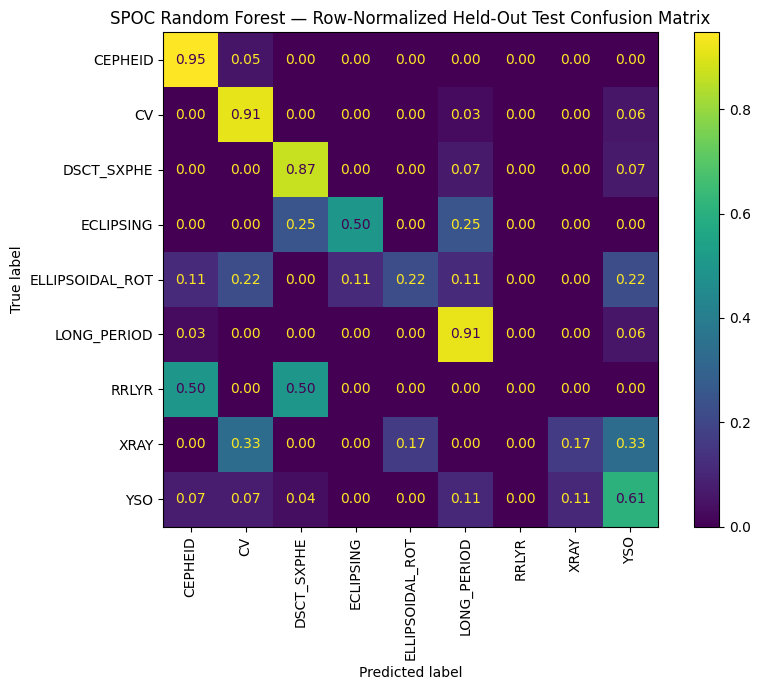

Saved: /data/projects/TESS-research/ml_analytics/output/matched_spoc_tesscut_tesscut_confusion_matrix_normalized.png


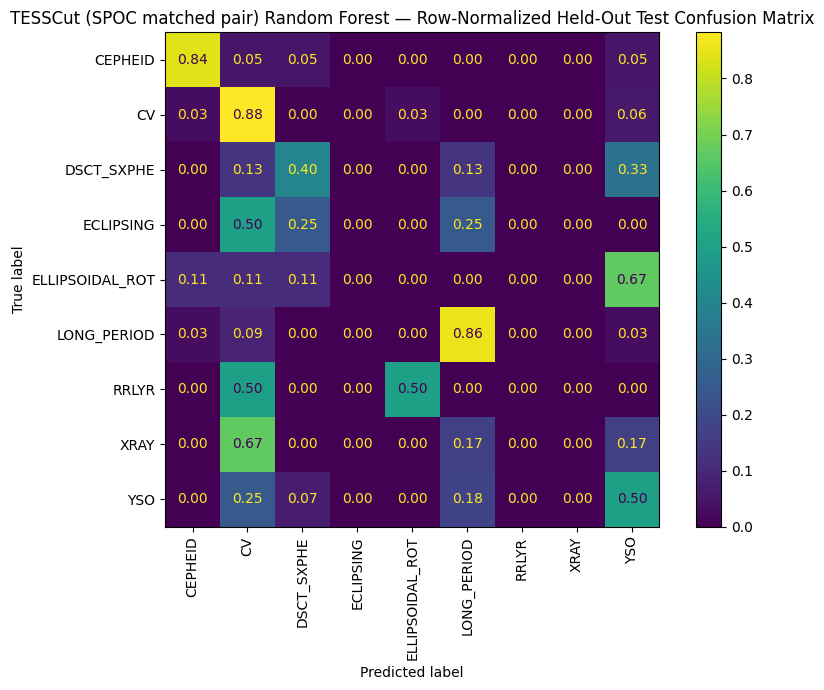

Matched QLP--TESSCut controlled confusion matrices:
Saved: /data/projects/TESS-research/ml_analytics/output/matched_qlp_tesscut_qlp_confusion_matrix_normalized.png


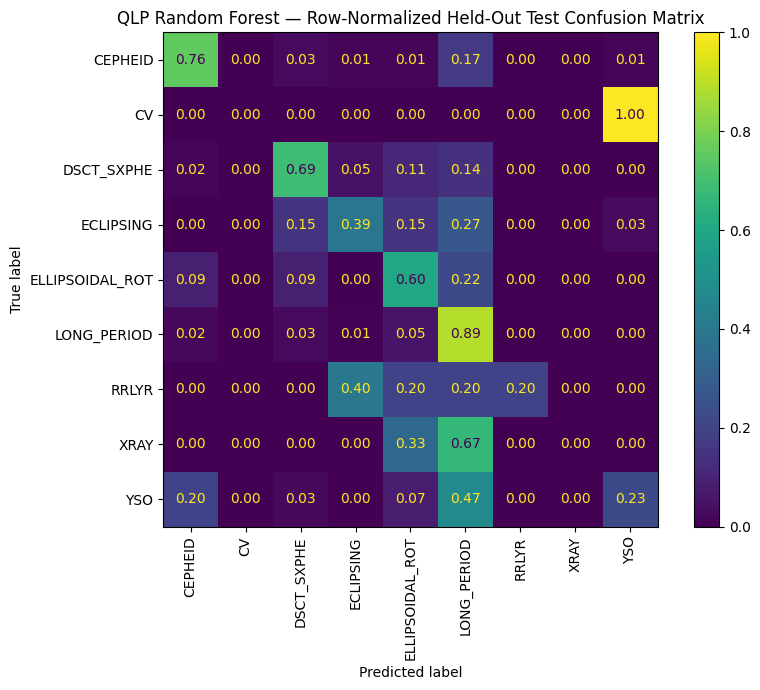

Saved: /data/projects/TESS-research/ml_analytics/output/matched_qlp_tesscut_tesscut_confusion_matrix_normalized.png


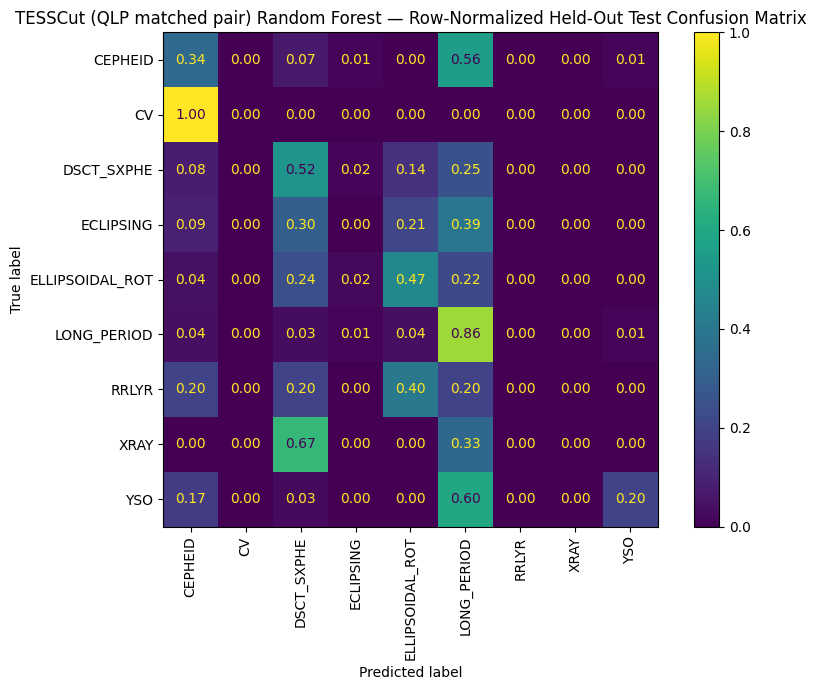

In [34]:
# ============================================================
# Controlled matched-test confusion matrices
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

def plot_matched_confusion_pair(results, official_provenance, output_prefix):
    labels = results["confusion_labels"]

    for provenance_name, matrix, suffix in [
        (
            official_provenance,
            results["official_confusion_matrix"],
            official_provenance.lower(),
        ),
        (
            "TESSCut",
            results["tesscut_confusion_matrix"],
            "tesscut",
        ),
    ]:
        fig, ax = plt.subplots(figsize=(9, 7))
        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=labels,
        ).plot(
            ax=ax,
            xticks_rotation=90,
            values_format=".2f",
            colorbar=True,
        )

        pair_text = (
            official_provenance
            if provenance_name == official_provenance
            else f"TESSCut ({official_provenance} matched pair)"
        )
        ax.set_title(
            f"{pair_text} Random Forest — "
            "Row-Normalized Held-Out Test Confusion Matrix"
        )
        fig.tight_layout()

        figure_path = (
            OutputDir
            / f"{output_prefix}_{suffix}_confusion_matrix_normalized.png"
        )
        fig.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved: {figure_path}")
        plt.show()
        plt.close(fig)


print("Matched SPOC--TESSCut controlled confusion matrices:")
plot_matched_confusion_pair(
    SpocTessCutMatchedResults,
    "SPOC",
    "matched_spoc_tesscut",
)

print("Matched QLP--TESSCut controlled confusion matrices:")
plot_matched_confusion_pair(
    QlpTessCutMatchedResults,
    "QLP",
    "matched_qlp_tesscut",
)


## Step 23 — Final Interpretation of the Matched Provenance Comparisons

The matched experiments use identical `VSXId` objects, labels, train/test stars, predictors, and Random Forest configuration.

- **SPOC vs. TESSCut:** accuracy **0.763 vs. 0.632**; balanced accuracy **0.571 vs. 0.387**.
- **QLP vs. TESSCut:** accuracy **0.681 vs. 0.518**; balanced accuracy **0.417 vs. 0.265**.
- SPOC–TESSCut importance-rank correlation: RF built-in **ρ = 0.720**; permutation **ρ = −0.017**.
- QLP–TESSCut importance-rank correlation: RF built-in **ρ = 0.635**; permutation **ρ = 0.361**.

The same stars therefore yield substantially different classification performance and model-dependence structures under different TESS light-curve products. These differences cannot be attributed to star identity or train/test composition within the matched comparisons.

The result is a **provenance-associated effect**; photometric extraction, preprocessing, sampling, and noise characteristics are components of provenance and are not individually isolated by this experiment.


## Corrected official results after excluding ProvenanceScore

The following values are the official headline results from the rerun without `ProvenanceScore` as a predictor:

- Mixed-provenance held-out accuracy: SPOC 75.0%, QLP 63.5%, TESSCut 31.4%.
- Separate provenance-specific model accuracy: SPOC 75.7%, QLP 71.1%, TESSCut 32.5%.
- Matched SPOC vs. TESSCut accuracy: 76.3% vs. 63.2% (13.2 percentage-point gap).
- Matched QLP vs. TESSCut accuracy: 68.1% vs. 51.8% (16.2 percentage-point gap).
- Matched SPOC vs. TESSCut balanced accuracy: 57.1% vs. 38.7%.
- Matched QLP vs. TESSCut balanced accuracy: 41.7% vs. 26.5%.
- Matched feature-importance rank correlations:
  - SPOC--TESSCut: built-in RF rho = 0.720; permutation rho = -0.017.
  - QLP--TESSCut: built-in RF rho = 0.635; permutation rho = 0.361.

Interpretation: removing the explicit provenance encoding does not weaken the central provenance conclusion. The matched-star performance differences persist, while feature-importance rankings continue to differ materially across provenance.


### Terminology note: `fluxSnr`

Earlier versions stored $R_{\mathrm{flux}}=|\operatorname{median}(f)|/\operatorname{std}(f)$ under the historical names `fluxSnr`, `OriginalFluxSnr`, and `LowSnr`. This quantity is **not a formal photometric signal-to-noise ratio** because the light-curve standard deviation includes intrinsic stellar variability, residual systematics, and measurement noise.

The analysis interprets it as an empirical **median-to-scatter ratio**. The historical condition `LowSnr = True`, corresponding to $R_{\mathrm{flux}}<3$, is a **high-relative-scatter flag** rather than direct evidence of poor photometric signal-to-noise.

Historical column names remain unchanged for compatibility; this terminology clarification does not alter stored values or model results.
